# Figure 4.3d

# Figure 4.3a – Heatmaps for representative phase-diagram points

# Figure 4.3b — Performance vs alpha (continuous)

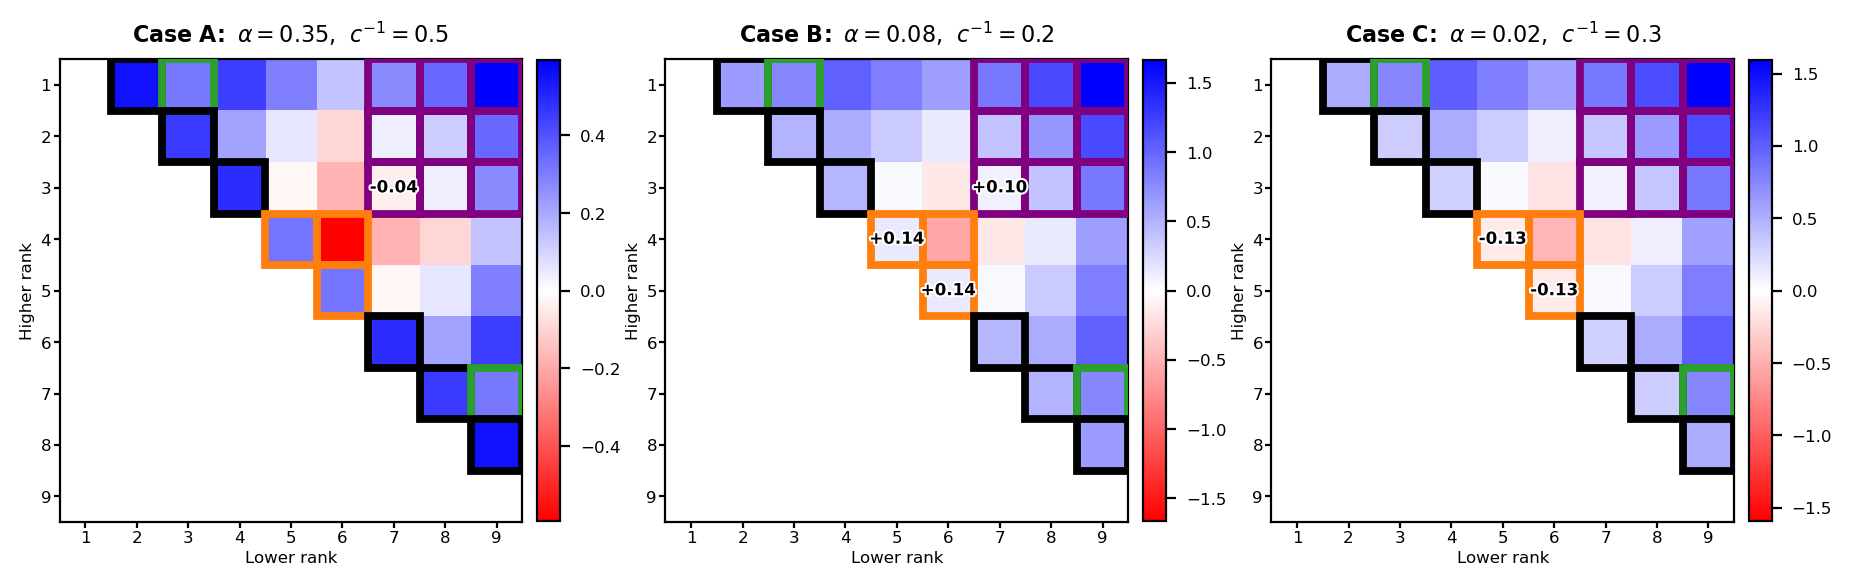

In [5]:
#3 heatmaps
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from Ranking_exp import Ranking_exp


def _build_matrix(sub: pd.DataFrame, metric: str):
    agg = (
        sub.groupby(["rank_higher", "rank_lower", "seed"])[metric].mean()
        .reset_index()
        .groupby(["rank_higher", "rank_lower"])[metric].mean()
        .reset_index()
    )
    meta = (
        sub.groupby(["rank_higher", "rank_lower"])[
            ["is_train", "is_exception", "within_gen", "across_gen"]
        ]
        .first()
        .reset_index()
    )
    agg = agg.merge(meta, on=["rank_higher", "rank_lower"])
    n = int(agg[["rank_higher", "rank_lower"]].max().max()) + 1
    M                = np.full((n, n), np.nan)
    train_mask       = np.zeros((n, n), dtype=bool)
    exc_mask         = np.zeros((n, n), dtype=bool)
    within_gen_mask  = np.zeros((n, n), dtype=bool)
    across_gen_mask  = np.zeros((n, n), dtype=bool)
    for _, row in agg.iterrows():
        i, j = int(row["rank_higher"]), int(row["rank_lower"])
        M[i, j] = row[metric]
        if row["is_train"] and not row["is_exception"]:
            train_mask[i, j] = True
        elif row["is_exception"]:
            exc_mask[i, j] = True
        elif row["within_gen"]:
            within_gen_mask[i, j] = True
        elif row["across_gen"]:
            across_gen_mask[i, j] = True

    # Keep only the diagonal and upper triangle (i <= j); hide the rest.
    lower = np.tril_indices(n, k=-1)
    M[lower]               = np.nan
    train_mask[lower]      = False
    exc_mask[lower]        = False
    within_gen_mask[lower] = False
    across_gen_mask[lower] = False

    return M, train_mask, exc_mask, within_gen_mask, across_gen_mask


def _draw_matrix(ax, M, train_mask, exc_mask, within_gen_mask, across_gen_mask,
                 *, cmap, vmin, vmax, fmt,
                 tick_labels=None, show_numbers=False,
                 annotate_cells=None, colorbar_label=""):
    n = M.shape[0]
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03, fraction=0.046)
    cb.set_label(colorbar_label, fontsize=6)
    cb.ax.tick_params(labelsize=6)

    if show_numbers:
        for i in range(n):
            for j in range(n):
                if not np.isnan(M[i, j]):
                    ax.text(j, i, f"{M[i, j]:{fmt}}", ha="center", va="center",
                            fontsize=6, color="black")
    elif annotate_cells:
        for (r1, c1) in annotate_cells:
            r0, c0 = r1 - 1, c1 - 1
            if not np.isnan(M[r0, c0]):
                ax.text(c0, r0, f"{M[r0, c0]:{fmt}}", ha="center", va="center",
                        fontsize=6, color="black", fontweight="bold", zorder=4,
                        path_effects=[pe.withStroke(linewidth=1.5, foreground="white")])

    lw    = 2.8
    inset = 0.00
    for i in range(n):
        for j in range(n):
            if train_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=False, edgecolor="black", lw=lw, zorder=3))
            elif exc_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=False, edgecolor="#ff7f0e", lw=lw, zorder=3))
            elif within_gen_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5+inset, i-0.5+inset),
                                           1-2*inset, 1-2*inset,
                             fill=False, edgecolor="#2ca02c", lw=lw, zorder=3))
            elif across_gen_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5+inset, i-0.5+inset),
                                           1-2*inset, 1-2*inset,
                             fill=False, edgecolor="purple", lw=lw, zorder=3))

    labels = tick_labels if tick_labels is not None else [str(k + 1) for k in range(n)]
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Lower rank", fontsize=6, labelpad=2)
    ax.set_ylabel("Higher rank", fontsize=6, labelpad=2)
    ax.tick_params(axis="both", length=2, pad=1)


# ── shared experiment parameters ──────────────────────────────────────
n   = 9
p   = 6
q   = 4
k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

# Representative conditions from the phase diagram
# (alpha, c_inv) → k_o = (1 - alpha)/2 * delta_s + k_d,  c_reg = 1 / (c_inv * delta_s)
conditions_alpha = [
    (0.35, 0.50),   # Case A
    (0.08, 0.20),   # Case B
    (0.02, 0.30),   # Case C
]
conditions = [((1 - a) / 2 * delta_s + k_d, c_inv) for a, c_inv in conditions_alpha]

# ── build one heatmap-DataFrame per condition ─────────────────────────
def build_fjk_df(n, p, q, k_o, c_reg, k_s, k_d):
    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)
    rows = []
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            margin = sim.f_j_k(i + 1, j + 1)
            transverse_pairs = (
                (i, j) in [(q-1, p-1), (q-1, q), (q, q+1)]
                or (i, j) in [(p-1, q-1), (p-1, q), (p-2, q-1)]
            )
            is_train = (i == j + 1) or (j == i + 1) #  or transverse_pairs

            # Section membership (0-indexed):
            #   O^(1) = {I_1, ..., I_{q-1}}  ->  indices {0, ..., q-2}
            #   O^(2) = {I_{p+1}, ..., I_n}  ->  indices {p, ..., n-1}
            in_O1_i = i < q - 1
            in_O1_j = j < q - 1
            in_O2_i = i >= p
            in_O2_j = j >= p
            within_gen = (in_O1_i and in_O1_j) or (in_O2_i and in_O2_j)
            across_gen = (in_O1_i and in_O2_j) or (in_O2_i and in_O1_j)

            rows.append({
                "phase":        "post",
                "seed":         0,
                "rank_higher":  i,
                "rank_lower":   j,
                "margin":       margin,
                "correct":      1 if margin > 0 else 0,
                "is_train":     is_train,
                "is_exception": transverse_pairs,
                "within_gen":   within_gen,
                "across_gen":   across_gen,
            })
    return pd.DataFrame(rows)


# ── plot: three columns of margin heatmaps ────────────────────────────
with plt.rc_context({"figure.dpi": 200}):
    fig, axes = plt.subplots(1, 3, figsize=(9.2, 3.0))

    # Per-condition margin annotations: 1-indexed (row, col) tuples.
    annotate_cells_map = {
        0: [(3, 7)],
        1: [(3, 7), (4, 5), (5, 6)],
        2: [(4, 5), (5, 6)],
    }

    # Per-condition title prefixes (bolded via mathtext \mathbf).
    title_prefix_map = {
        0: r"$\mathbf{Case\ A\!:}$ ",
        1: r"$\mathbf{Case\ B\!:}$ ",
        2: r"$\mathbf{Case\ C\!:}$ ",
    }

    for idx, ((k_o, c_inv), (alpha_c, _)) in enumerate(zip(conditions, conditions_alpha)):
        c_reg = 1.0 / (c_inv * delta_s)
        df = build_fjk_df(n, p, q, k_o, c_reg, k_s, k_d)
        sub = df[df["phase"] == "post"].copy()
        M_m, tm, em, wgm, agm = _build_matrix(sub, "margin")
        ext = max(abs(np.nanmax(M_m)), abs(np.nanmin(M_m)), 0.1)

        ax = axes[idx]
        _draw_matrix(
            ax, M_m, tm, em, wgm, agm,
            cmap="bwr_r", vmin=-ext, vmax=ext, fmt="+.2f",
            show_numbers=False,
            annotate_cells=annotate_cells_map.get(idx, []),
            colorbar_label="",
        )
        ax.set_title(
            f"{title_prefix_map.get(idx, '')}$\\alpha={alpha_c:.2f}$,  $c^{{-1}}={c_inv}$",
            fontsize=8, pad=6,
        )

    # fig.suptitle(
    #     f"Figure 4.3a — Representative $f(j,k)$ heatmaps  "
    #     f"(n={n}, p={p}, q={q})",
    #     fontsize=10, y=1.04,
    # )
    plt.tight_layout(pad=0.5, w_pad=0.2)
    plt.show()
    fig.savefig("figure_4_3a.pdf", bbox_inches="tight")

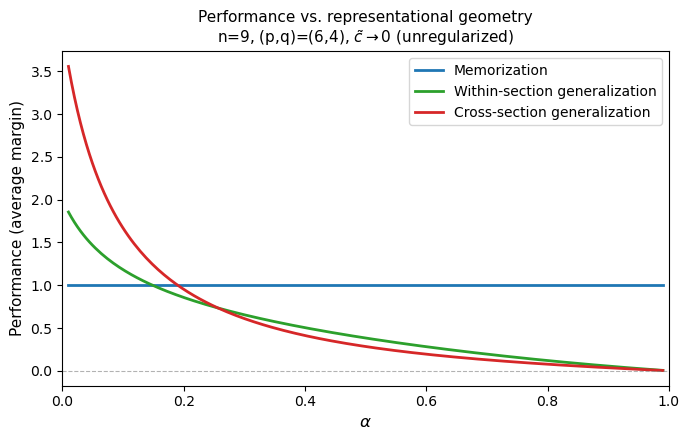

In [6]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ── Parameters ──────────────────────────────────────────────────────────────
n, p, q = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg = 1e8  # unregularized

# Sections (1-indexed):
#   O(1) = {1, ..., q-1} = {1, 2, 3}
#   O(2) = {p+1, ..., n} = {7, 8, 9}
#   Loop = {q, ..., p}   = {4, 5, 6}
O1 = list(range(1, q))        # [1, 2, 3]
O2 = list(range(p + 1, n + 1))  # [7, 8, 9]

# ── Define pair sets ────────────────────────────────────────────────────────
# Training pairs: adjacent (j, j+1) for j=1..n-1, plus exception (p, q)
train_pairs = [(j, j + 1) for j in range(1, n)] + [(p, q)]

# Within-section generalization: non-adjacent pairs within O(1) or O(2)
within_pairs = []
for section in [O1, O2]:
    for j in section:
        for k in section:
            if j < k and abs(j - k) >= 2:
                within_pairs.append((j, k))

# Cross-section generalization: pairs across O(1) and O(2)
cross_pairs = []
for j in O1:
    for k in O2:
        cross_pairs.append((j, k))  # expect f(j,k) > 0 since j < k

# ── Sweep alpha ─────────────────────────────────────────────────────────────
alphas = np.linspace(0.01, 0.99, 200)

mem_perf = np.zeros(len(alphas))
within_perf = np.zeros(len(alphas))
cross_perf = np.zeros(len(alphas))

for idx, alpha in enumerate(alphas):
    k_o = (1 - alpha) / 2 * (k_s - k_d) + k_d
    # alpha = 1 - 2*(k_o - k_d)/(k_s - k_d), so k_o = (1-alpha)/2 * delta_s + k_d

    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)

    # Memorization: average margin on training pairs
    margins = []
    for (j, k) in train_pairs:
        margins.append(sim.f_j_k(j, k))
    mem_perf[idx] = np.mean(margins)

    # Within-section generalization: average margin
    if within_pairs:
        margins = []
        for (j, k) in within_pairs:
            margins.append(sim.f_j_k(j, k))
        within_perf[idx] = np.mean(margins)

    # Cross-section generalization: average margin
    if cross_pairs:
        margins = []
        for (j, k) in cross_pairs:
            margins.append(sim.f_j_k(j, k))
        cross_perf[idx] = np.mean(margins)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(alphas, mem_perf, lw=2, color='#1f77b4', label='Memorization')
ax.plot(alphas, within_perf, lw=2, color='#2ca02c', label='Within-section generalization')
ax.plot(alphas, cross_perf, lw=2, color='#d62728', label='Cross-section generalization')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$', fontsize=12)
ax.set_ylabel('Performance (average margin)', fontsize=11)
ax.set_title(f'Performance vs. representational geometry\nn={n}, (p,q)=({p},{q}), '
             r'$\tilde{c}\to 0$ (unregularized)', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
fig.savefig("figure_4.3b.pdf", bbox_inches="tight")

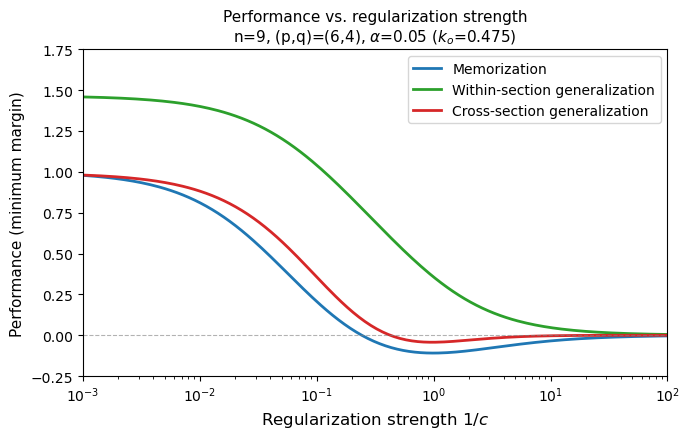

In [7]:
#figure 3b part 2
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ── Parameters ──────────────────────────────────────────────────────────────
n, p, q = 9, 6, 4
k_s, k_d = 1.0, 0.0

# Representational geometry held fixed; sweep regularization strength 1/c
alpha_fixed = 0.05
k_o = (1 - alpha_fixed) / 2 * (k_s - k_d) + k_d

# Sections (1-indexed):
#   O(1) = {1, ..., q-1} = {1, 2, 3}
#   O(2) = {p+1, ..., n} = {7, 8, 9}
#   Loop = {q, ..., p}   = {4, 5, 6}
O1 = list(range(1, q))        # [1, 2, 3]
O2 = list(range(p + 1, n + 1))  # [7, 8, 9]

# ── Define pair sets ────────────────────────────────────────────────────────
# Training pairs: adjacent (j, j+1) for j=1..n-1, plus exception (p, q)
train_pairs = [(j, j + 1) for j in range(1, n)] + [(p, q)]

# Within-section generalization: non-adjacent pairs within O(1) or O(2)
within_pairs = []
for section in [O1, O2]:
    for j in section:
        for k in section:
            if j < k and abs(j - k) >= 2:
                within_pairs.append((j, k))

# Cross-section generalization: pairs across O(1) and O(2)
cross_pairs = []
for j in O1:
    for k in O2:
        cross_pairs.append((j, k))  # expect f(j,k) > 0 since j < k

# ── Sweep regularization strength 1/c ───────────────────────────────────────
# Small 1/c  ≈ unregularized; large 1/c ≈ strongly regularized.
c_inv_vals = np.logspace(-3, 2, 200)

mem_perf = np.zeros(len(c_inv_vals))
within_perf = np.zeros(len(c_inv_vals))
cross_perf = np.zeros(len(c_inv_vals))

for idx, c_inv in enumerate(c_inv_vals):
    c_reg_cur = 1.0 / c_inv

    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg_cur)

    # Memorization: minimum margin on training pairs
    margins = []
    for (j, k) in train_pairs:
        margins.append(sim.f_j_k(j, k))
    mem_perf[idx] = np.min(margins)

    # Within-section generalization: minimum margin
    if within_pairs:
        margins = []
        for (j, k) in within_pairs:
            margins.append(sim.f_j_k(j, k))
        within_perf[idx] = np.min(margins)

    # Cross-section generalization: minimum margin
    if cross_pairs:
        margins = []
        for (j, k) in cross_pairs:
            margins.append(sim.f_j_k(j, k))
        cross_perf[idx] = np.min(margins)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(c_inv_vals, mem_perf, lw=2, color='#1f77b4', label='Memorization')
ax.plot(c_inv_vals, within_perf, lw=2, color='#2ca02c', label='Within-section generalization')
ax.plot(c_inv_vals, cross_perf, lw=2, color='#d62728', label='Cross-section generalization')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel(r'Regularization strength $1/c$', fontsize=12)
ax.set_ylabel('Performance (minimum margin)', fontsize=11)
ax.set_title(f'Performance vs. regularization strength\nn={n}, (p,q)=({p},{q}), '
             rf'$\alpha$={alpha_fixed:.2f} ($k_o$={k_o:.3f})', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(c_inv_vals[0], c_inv_vals[-1])
ax.set_ylim(-0.25, 1.75)
plt.tight_layout()
plt.show()
fig.savefig("figure_4.3b2_min_margin_reg.pdf", bbox_inches="tight")

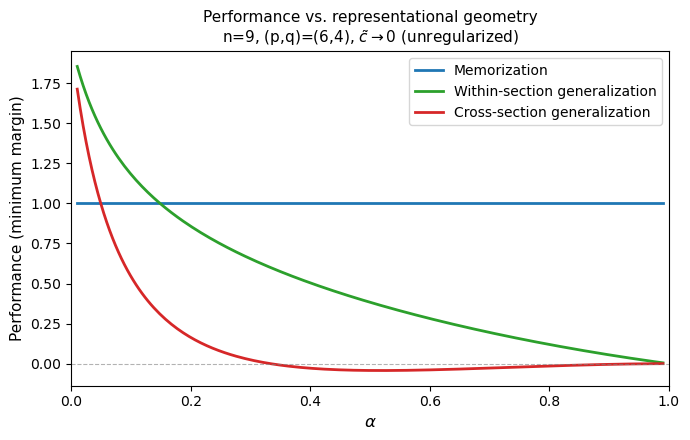

In [8]:
#figure 3b part 1
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ── Parameters ──────────────────────────────────────────────────────────────
n, p, q = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg = 1e8  # unregularized

# Sections (1-indexed):
#   O(1) = {1, ..., q-1} = {1, 2, 3}
#   O(2) = {p+1, ..., n} = {7, 8, 9}
#   Loop = {q, ..., p}   = {4, 5, 6}
O1 = list(range(1, q))        # [1, 2, 3]
O2 = list(range(p + 1, n + 1))  # [7, 8, 9]

# ── Define pair sets ────────────────────────────────────────────────────────
# Training pairs: adjacent (j, j+1) for j=1..n-1, plus exception (p, q)
train_pairs = [(j, j + 1) for j in range(1, n)] + [(p, q)]

# Within-section generalization: non-adjacent pairs within O(1) or O(2)
within_pairs = []
for section in [O1, O2]:
    for j in section:
        for k in section:
            if j < k and abs(j - k) >= 2:
                within_pairs.append((j, k))

# Cross-section generalization: pairs across O(1) and O(2)
cross_pairs = []
for j in O1:
    for k in O2:
        cross_pairs.append((j, k))  # expect f(j,k) > 0 since j < k

# ── Sweep alpha ─────────────────────────────────────────────────────────────
alphas = np.linspace(0.01, 0.99, 200)

mem_perf = np.zeros(len(alphas))
within_perf = np.zeros(len(alphas))
cross_perf = np.zeros(len(alphas))

for idx, alpha in enumerate(alphas):
    k_o = (1 - alpha) / 2 * (k_s - k_d) + k_d

    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)

    # Memorization: minimum margin on training pairs
    margins = []
    for (j, k) in train_pairs:
        margins.append(sim.f_j_k(j, k))
    mem_perf[idx] = np.min(margins)

    # Within-section generalization: minimum margin
    if within_pairs:
        margins = []
        for (j, k) in within_pairs:
            margins.append(sim.f_j_k(j, k))
        within_perf[idx] = np.min(margins)

    # Cross-section generalization: minimum margin
    if cross_pairs:
        margins = []
        for (j, k) in cross_pairs:
            margins.append(sim.f_j_k(j, k))
        cross_perf[idx] = np.min(margins)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(alphas, mem_perf, lw=2, color='#1f77b4', label='Memorization')
ax.plot(alphas, within_perf, lw=2, color='#2ca02c', label='Within-section generalization')
ax.plot(alphas, cross_perf, lw=2, color='#d62728', label='Cross-section generalization')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$', fontsize=12)
ax.set_ylabel('Performance (minimum margin)', fontsize=11)
ax.set_title(f'Performance vs. representational geometry\nn={n}, (p,q)=({p},{q}), '
             r'$\tilde{c}\to 0$ (unregularized)', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
fig.savefig("figure_4.3b_min_margin.pdf", bbox_inches="tight")

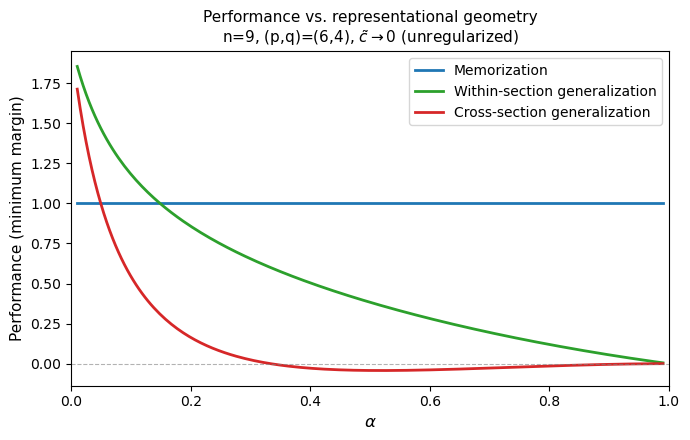

In [9]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import contextlib, io
import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

# ── Parameters ──────────────────────────────────────────────────────────────
n, p, q = 9, 6, 4
k_s, k_d = 1.0, 0.0
c_reg = 1e8  # unregularized

# Sections (1-indexed):
#   O(1) = {1, ..., q-1} = {1, 2, 3}
#   O(2) = {p+1, ..., n} = {7, 8, 9}
#   Loop = {q, ..., p}   = {4, 5, 6}
O1 = list(range(1, q))        # [1, 2, 3]
O2 = list(range(p + 1, n + 1))  # [7, 8, 9]

# ── Define pair sets ────────────────────────────────────────────────────────
# Training pairs: adjacent (j, j+1) for j=1..n-1, plus exception (p, q)
train_pairs = [(j, j + 1) for j in range(1, n)] + [(p, q)]

# Within-section generalization: non-adjacent pairs within O(1) or O(2)
within_pairs = []
for section in [O1, O2]:
    for j in section:
        for k in section:
            if j < k and abs(j - k) >= 2:
                within_pairs.append((j, k))

# Cross-section generalization: pairs across O(1) and O(2)
cross_pairs = []
for j in O1:
    for k in O2:
        cross_pairs.append((j, k))  # expect f(j,k) > 0 since j < k

# ── Sweep alpha ─────────────────────────────────────────────────────────────
alphas = np.linspace(0.01, 0.99, 200)

mem_perf = np.zeros(len(alphas))
within_perf = np.zeros(len(alphas))
cross_perf = np.zeros(len(alphas))

for idx, alpha in enumerate(alphas):
    k_o = (1 - alpha) / 2 * (k_s - k_d) + k_d

    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                          p=p, q=q, c_reg=c_reg)

    # Memorization: minimum margin on training pairs
    margins = []
    for (j, k) in train_pairs:
        margins.append(sim.f_j_k(j, k))
    mem_perf[idx] = np.min(margins)

    # Within-section generalization: minimum margin
    if within_pairs:
        margins = []
        for (j, k) in within_pairs:
            margins.append(sim.f_j_k(j, k))
        within_perf[idx] = np.min(margins)

    # Cross-section generalization: minimum margin
    if cross_pairs:
        margins = []
        for (j, k) in cross_pairs:
            margins.append(sim.f_j_k(j, k))
        cross_perf[idx] = np.min(margins)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(alphas, mem_perf, lw=2, color='#1f77b4', label='Memorization')
ax.plot(alphas, within_perf, lw=2, color='#2ca02c', label='Within-section generalization')
ax.plot(alphas, cross_perf, lw=2, color='#d62728', label='Cross-section generalization')

ax.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel(r'$\alpha$', fontsize=12)
ax.set_ylabel('Performance (minimum margin)', fontsize=11)
ax.set_title(f'Performance vs. representational geometry\nn={n}, (p,q)=({p},{q}), '
             r'$\tilde{c}\to 0$ (unregularized)', fontsize=11)
ax.legend(loc='best', fontsize=10)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
fig.savefig("figure_4.3b_min_margin.pdf", bbox_inches="tight")

Validation passed on 5 sampled k_o values.


k_o sweep (bisect):   0%|          | 0/200 [00:00<?, ?it/s]

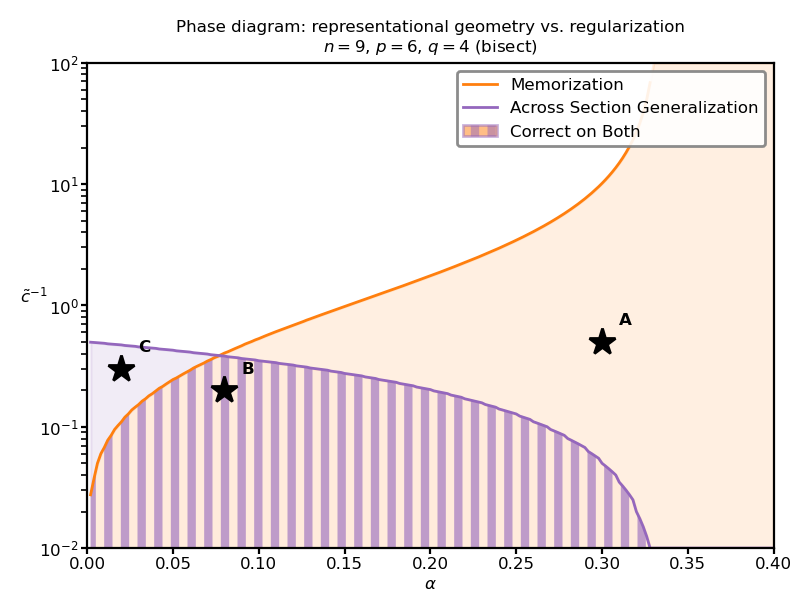

In [10]:
#figure 3c

# ---- Tier 1 + Tier 2: binary-search sweep (assumes monotonicity in c_reg) ----
# Builds one Ranking_exp per probe (not per critical-pair); bisects the
# c_var index at which each margin first flips negative.
#
# Before running the full sweep, we validate against the linear scan on a
# small sample of k_o values so we'd catch any non-monotonic cases.

import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from Ranking_exp import Ranking_exp

# ------------------------- parameters (identical to linear sweep) ------------
n = 9
p = 6
q = 4
k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

k_o_vals   = np.arange(0.30, 0.4999, 0.001)
alpha_vals = 1.0 - 2.0 * (k_o_vals - k_d) / (k_s - k_d)
c_var_vals = np.arange(1e-2, 100, 0.0025)
c_vals     = 1.0 / (c_var_vals * delta_s)

test_critical_pair  = (q - 1, p + 1)
train_critical_pair = (q,     q + 1)


# ------------------------- helpers -------------------------------------------
def _make_sim(k_o, cr):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                           p=p, q=q, c_reg=cr)


def bisect_flip_both(k_o):
    """Return (c_var_test, c_var_train) at first flip, NaN if never flips.

    Uses one bisect per critical pair, reusing the sim at each probed index.
    """
    N = len(c_vals)

    def sim_at(i, _cache={}):
        if i not in _cache:
            _cache[i] = _make_sim(k_o, c_vals[i])
        return _cache[i]

    def first_flip(pair):
        # If the last c_reg (weakest regularization) hasn't flipped, skip.
        if sim_at(N - 1).f_j_k(*pair) >= 0:
            return np.nan
        lo, hi = 0, N - 1
        while lo < hi:
            mid = (lo + hi) // 2
            if sim_at(mid).f_j_k(*pair) < 0:
                hi = mid
            else:
                lo = mid + 1
        return c_var_vals[lo]

    return first_flip(test_critical_pair), first_flip(train_critical_pair)


def linear_flip_both(k_o):
    """Reference linear scan, for validation."""
    ft = None
    fr = None
    for i, cr in enumerate(c_vals):
        sim = _make_sim(k_o, cr)
        if ft is None and sim.f_j_k(*test_critical_pair) < 0:
            ft = c_var_vals[i]
        if fr is None and sim.f_j_k(*train_critical_pair) < 0:
            fr = c_var_vals[i]
        if ft is not None and fr is not None:
            break
    return (ft if ft is not None else np.nan,
            fr if fr is not None else np.nan)


# ------------------------- validation -----------------------------------------
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(k_o_vals), size=5, replace=False)
for si in sample_idx:
    k_o = k_o_vals[si]
    bt, br = bisect_flip_both(k_o)
    lt, lr = linear_flip_both(k_o)
    assert np.isclose(bt, lt, equal_nan=True) and np.isclose(br, lr, equal_nan=True), \
        f"Mismatch at k_o={k_o:.4f}: bisect=({bt},{br}) linear=({lt},{lr})"
print("Validation passed on 5 sampled k_o values.")


# ------------------------- full bisect sweep ---------------------------------
breaking_reg_test  = np.zeros_like(k_o_vals)
breaking_reg_train = np.zeros_like(k_o_vals)

for idx, k_o in enumerate(tqdm(k_o_vals, desc='k_o sweep (bisect)')):
    breaking_reg_test[idx], breaking_reg_train[idx] = bisect_flip_both(k_o)


# ------------------------- plot ----------------------------------------------
import matplotlib.patches as mpatches

train = breaking_reg_train
test  = breaking_reg_test

ylim_bot = 1e-2
ylim_top = 1e2
train_fill   = np.where(np.isnan(train), ylim_top, train)
test_fill    = np.where(np.isnan(test),  ylim_top, test)
overlap_fill = np.minimum(train_fill, test_fill)

ORANGE = '#ff7f0e'
PURPLE = '#9467bd'

case_conditions = [
    (1 - 2*0.35, 0.50, 'A'),
    (1 - 2*0.46, 0.20, 'B'),
    (1 - 2*0.49, 0.30, 'C'),
]

with plt.rc_context({'figure.dpi': 200, 'hatch.linewidth': 3.0}):
    fig, ax = plt.subplots(figsize=(4, 3.0))

    ax.plot(alpha_vals, train, lw=1.0, color=ORANGE,
            label='Memorization')
    ax.plot(alpha_vals, test,  lw=1.0, color=PURPLE,
            label='Across Section Generalization')

    ax.fill_between(alpha_vals, overlap_fill, train_fill,
                    where=(train_fill > test_fill), interpolate=True,
                    alpha=0.12, color=ORANGE)
    ax.fill_between(alpha_vals, overlap_fill, test_fill,
                    where=(test_fill > train_fill), interpolate=True,
                    alpha=0.12, color=PURPLE)

    ax.fill_between(alpha_vals, ylim_bot, overlap_fill,
                    facecolor=ORANGE, alpha=0.15)
    ax.fill_between(alpha_vals, ylim_bot, overlap_fill, facecolor='none',
                    edgecolor=PURPLE, hatch='||', linewidth=0, alpha=0.6)
    ax.add_patch(mpatches.Rectangle((0,0),0,0,
                 facecolor=ORANGE, edgecolor=PURPLE, hatch='||',
                 alpha=0.5, label='Correct on Both'))

    for alpha_c, c_inv_c, case_lbl in case_conditions:
        ax.plot(alpha_c, c_inv_c, marker='*', markersize=10, color='black',
                zorder=5)
        ax.annotate(f'{case_lbl}', (alpha_c, c_inv_c),
                    textcoords='offset points', xytext=(6, 6),
                    fontsize=6, fontweight='bold')

    ax.set_xlabel(r'$\alpha$', fontsize=6, labelpad=2)
    ax.set_ylabel(r'$\tilde{c}^{-1}$', fontsize=6, rotation=0, labelpad=2)
    ax.set_title(
        f'Phase diagram: representational geometry vs. regularization\n'
        f'$n={n}$, $p={p}$, $q={q}$ (bisect)',
        fontsize=6, pad=4
    )
    ax.legend(fontsize=6, framealpha=0.9, edgecolor='gray', loc='upper right')
    ax.tick_params(axis='both', length=2, pad=1, labelsize=6)

    ax.set_yscale('log')
    ax.set_xlim(0.0, 0.40)
    ax.set_ylim(ylim_bot, ylim_top)
    ax.grid(False)

    plt.tight_layout(pad=0.5)
    plt.show()
    fig.savefig("figure_4e_bisect.pdf", bbox_inches="tight")


phase diagram sweep:   0%|          | 0/200 [00:00<?, ?it/s]

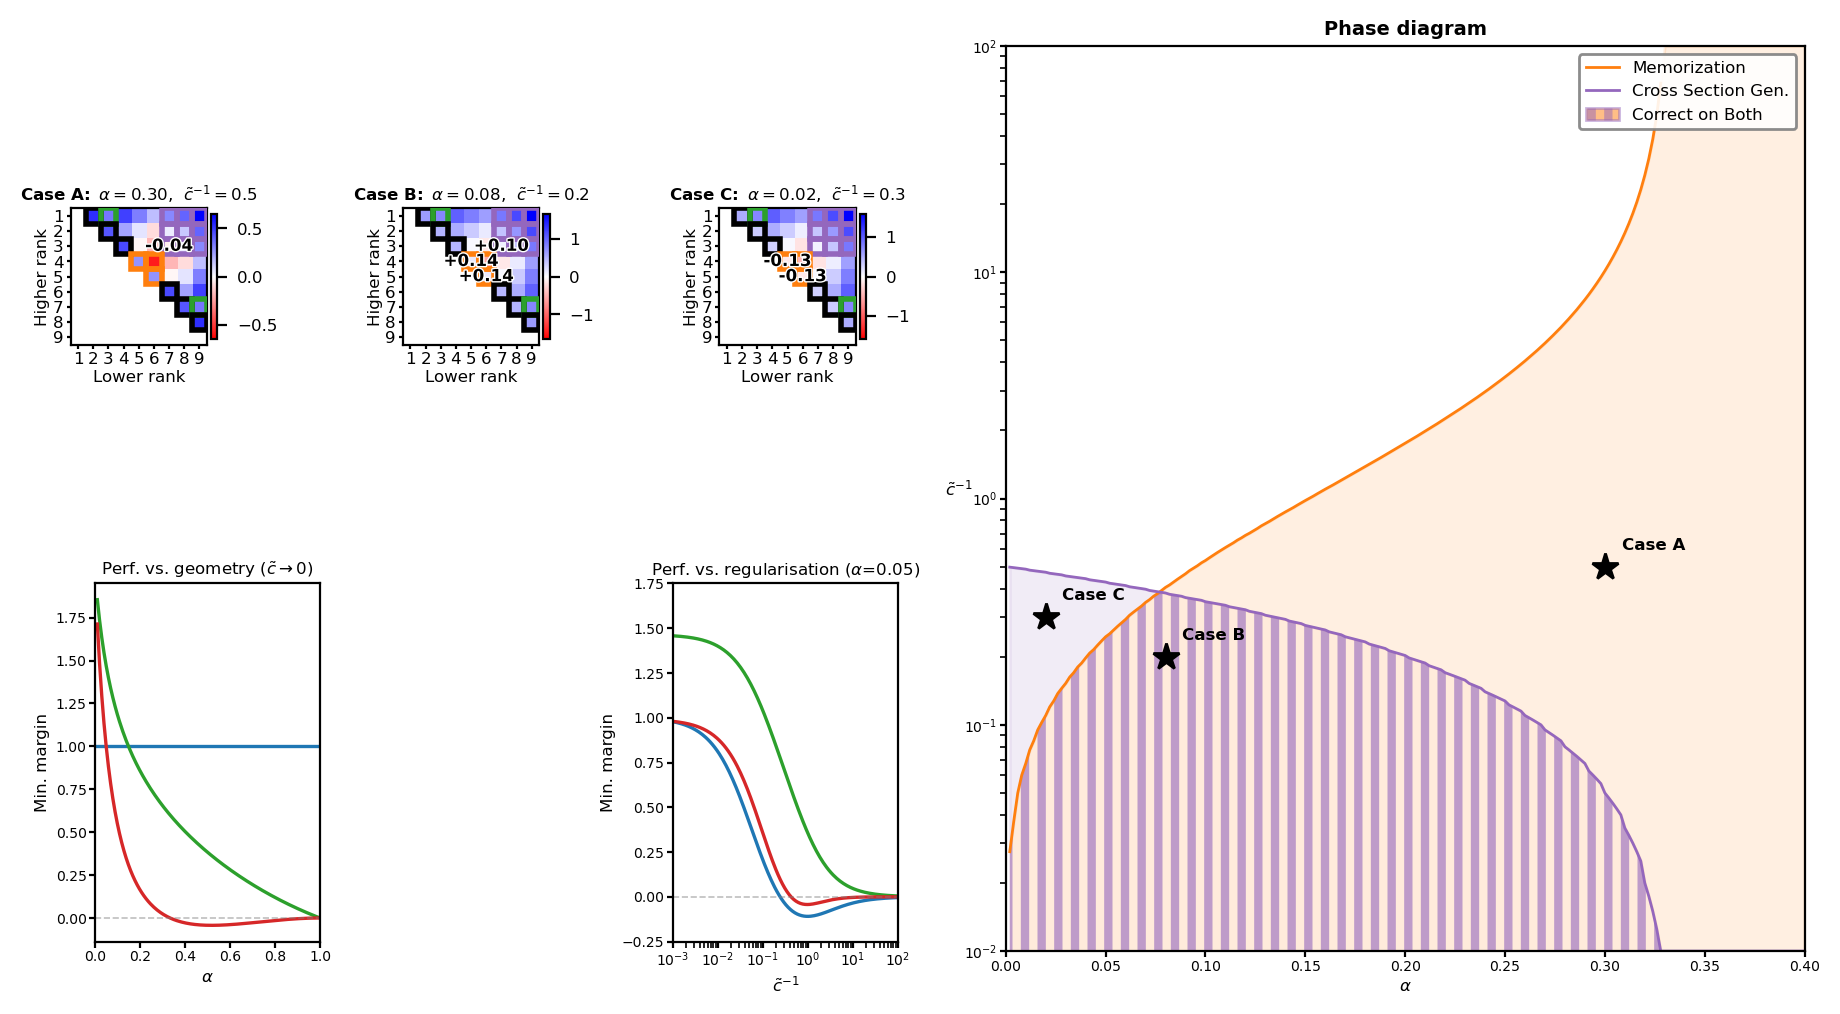

Saved → figure_4_combined.pdf


In [35]:
# ═══════════════════════════════════════════════════════════════════════════
# Combined figure: heatmaps (top-left), 3b plots (bottom-left), phase diagram (right)
# ═══════════════════════════════════════════════════════════════════════════
import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from tqdm.auto import tqdm
from Ranking_exp import Ranking_exp

FIG_W_IN = 325.48499 / 72.27

# ── shared parameters ─────────────────────────────────────────────────────
n, p, q = 9, 6, 4
k_s, k_d = 1.0, 0.0
delta_s = k_s - k_d

O1 = list(range(1, q))
O2 = list(range(p + 1, n + 1))

train_pairs = [(j, j + 1) for j in range(1, n)] + [(p, q)]
within_pairs = []
for section in [O1, O2]:
    for j in section:
        for k in section:
            if j < k and abs(j - k) >= 2:
                within_pairs.append((j, k))
cross_pairs = []
for j in O1:
    for k in O2:
        cross_pairs.append((j, k))

# ── heatmap helper: build f(j,k) dataframe ───────────────────────────────
def build_fjk_df(n, p, q, k_o, c_reg, k_s, k_d):
    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg)
    rows = []
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            margin = sim.f_j_k(i + 1, j + 1)
            transverse_pairs = (
                (i, j) in [(q-1, p-1), (q-1, q), (q, q+1)]
                or (i, j) in [(p-1, q-1), (p-1, q), (p-2, q-1)]
            )
            is_train = (i == j + 1) or (j == i + 1)
            in_O1_i = i < q - 1
            in_O1_j = j < q - 1
            in_O2_i = i >= p
            in_O2_j = j >= p
            within_gen = (in_O1_i and in_O1_j) or (in_O2_i and in_O2_j)
            across_gen = (in_O1_i and in_O2_j) or (in_O2_i and in_O1_j)
            rows.append({
                "phase": "post", "seed": 0,
                "rank_higher": i, "rank_lower": j,
                "margin": margin,
                "correct": 1 if margin > 0 else 0,
                "is_train": is_train, "is_exception": transverse_pairs,
                "within_gen": within_gen, "across_gen": across_gen,
            })
    return pd.DataFrame(rows)

def _build_matrix(sub, metric):
    agg = (sub.groupby(["rank_higher","rank_lower","seed"])[metric].mean()
           .reset_index().groupby(["rank_higher","rank_lower"])[metric].mean().reset_index())
    meta = (sub.groupby(["rank_higher","rank_lower"])[
        ["is_train","is_exception","within_gen","across_gen"]].first().reset_index())
    agg = agg.merge(meta, on=["rank_higher","rank_lower"])
    nn = int(agg[["rank_higher","rank_lower"]].max().max()) + 1
    M = np.full((nn,nn), np.nan)
    tm = np.zeros((nn,nn), dtype=bool)
    em = np.zeros((nn,nn), dtype=bool)
    wgm = np.zeros((nn,nn), dtype=bool)
    agm = np.zeros((nn,nn), dtype=bool)
    for _, row in agg.iterrows():
        i2, j2 = int(row["rank_higher"]), int(row["rank_lower"])
        M[i2,j2] = row[metric]
        if row["is_train"] and not row["is_exception"]: tm[i2,j2] = True
        elif row["is_exception"]: em[i2,j2] = True
        elif row["within_gen"]: wgm[i2,j2] = True
        elif row["across_gen"]: agm[i2,j2] = True
    lower = np.tril_indices(nn, k=-1)
    M[lower] = np.nan
    tm[lower] = False; em[lower] = False; wgm[lower] = False; agm[lower] = False
    return M, tm, em, wgm, agm

def _draw_matrix(ax, M, tm, em, wgm, agm, *, cmap, vmin, vmax, fmt,
                 tick_labels=None, show_numbers=False, annotate_cells=None,
                 colorbar_label=""):
    nn = M.shape[0]
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03, fraction=0.046)
    cb.set_label(colorbar_label, fontsize=6); cb.ax.tick_params(labelsize=6)
    if annotate_cells:
        for (r1,c1) in annotate_cells:
            r0, c0 = r1-1, c1-1
            if not np.isnan(M[r0,c0]):
                ax.text(c0,r0,f"{M[r0,c0]:{fmt}}", ha="center", va="center",
                        fontsize=6, color="black", fontweight="bold", zorder=4,
                        path_effects=[pe.withStroke(linewidth=1.0, foreground="white")])
    lw = 2.0
    for i2 in range(nn):
        for j2 in range(nn):
            if tm[i2,j2]:
                ax.add_patch(plt.Rectangle((j2-0.5,i2-0.5),1,1,fill=False,edgecolor="black",lw=lw,zorder=3))
            elif em[i2,j2]:
                ax.add_patch(plt.Rectangle((j2-0.5,i2-0.5),1,1,fill=False,edgecolor="#ff7f0e",lw=lw,zorder=3))
            elif wgm[i2,j2]:
                ax.add_patch(plt.Rectangle((j2-0.5,i2-0.5),1,1,fill=False,edgecolor="#2ca02c",lw=lw,zorder=3))
            elif agm[i2,j2]:
                ax.add_patch(plt.Rectangle((j2-0.5,i2-0.5),1,1,fill=False,edgecolor="tab:purple",lw=lw,zorder=3))
    labels = tick_labels if tick_labels is not None else [str(k+1) for k in range(nn)]
    ax.set_xticks(range(nn)); ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(nn)); ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Lower rank", fontsize=6, labelpad=1)
    ax.set_ylabel("Higher rank", fontsize=6, labelpad=1)
    ax.tick_params(axis="both", length=1.5, pad=1)

# ── compute 3b part 1: sweep alpha (unregularized) ───────────────────────
c_reg_unreg = 1e8
alphas_3b1 = np.linspace(0.01, 0.99, 200)
mem_perf_3b1    = np.zeros(len(alphas_3b1))
within_perf_3b1 = np.zeros(len(alphas_3b1))
cross_perf_3b1  = np.zeros(len(alphas_3b1))

for idx, alpha in enumerate(alphas_3b1):
    k_o = (1 - alpha) / 2 * (k_s - k_d) + k_d
    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg_unreg)
    mem_perf_3b1[idx]    = np.min([sim.f_j_k(j, k) for (j, k) in train_pairs])
    within_perf_3b1[idx] = np.min([sim.f_j_k(j, k) for (j, k) in within_pairs]) if within_pairs else 0
    cross_perf_3b1[idx]  = np.min([sim.f_j_k(j, k) for (j, k) in cross_pairs]) if cross_pairs else 0

# ── compute 3b part 2: sweep regularisation (fixed alpha=0.3) ─────────
alpha_fixed = 0.05
k_o_fixed = (1 - alpha_fixed) / 2 * (k_s - k_d) + k_d
c_inv_vals = np.logspace(-3, 2, 200)
mem_perf_3b2    = np.zeros(len(c_inv_vals))
within_perf_3b2 = np.zeros(len(c_inv_vals))
cross_perf_3b2  = np.zeros(len(c_inv_vals))

for idx, c_inv in enumerate(c_inv_vals):
    c_reg_cur = 1.0 / c_inv
    with contextlib.redirect_stdout(io.StringIO()):
        sim = Ranking_exp(n=n, k_o=k_o_fixed, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=c_reg_cur)
    mem_perf_3b2[idx]    = np.min([sim.f_j_k(j, k) for (j, k) in train_pairs])
    within_perf_3b2[idx] = np.min([sim.f_j_k(j, k) for (j, k) in within_pairs]) if within_pairs else 0
    cross_perf_3b2[idx]  = np.min([sim.f_j_k(j, k) for (j, k) in cross_pairs]) if cross_pairs else 0

# ── compute phase diagram (bisect) ───────────────────────────────────────
k_o_vals_pd   = np.arange(0.30, 0.4999, 0.001)
alpha_vals_pd = 1.0 - 2.0 * (k_o_vals_pd - k_d) / (k_s - k_d)
c_var_vals_pd = np.arange(1e-2, 100, 0.0025)
c_vals_pd     = 1.0 / (c_var_vals_pd * delta_s)

test_critical_pair  = (q - 1, p + 1)
train_critical_pair = (q,     q + 1)

def _make_sim(k_o, cr):
    with contextlib.redirect_stdout(io.StringIO()):
        return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d, p=p, q=q, c_reg=cr)

def bisect_flip_both(k_o):
    N = len(c_vals_pd)
    _cache = {}
    def sim_at(i):
        if i not in _cache:
            _cache[i] = _make_sim(k_o, c_vals_pd[i])
        return _cache[i]
    def first_flip(pair):
        if sim_at(N - 1).f_j_k(*pair) >= 0:
            return np.nan
        lo, hi = 0, N - 1
        while lo < hi:
            mid = (lo + hi) // 2
            if sim_at(mid).f_j_k(*pair) < 0:
                hi = mid
            else:
                lo = mid + 1
        return c_var_vals_pd[lo]
    return first_flip(test_critical_pair), first_flip(train_critical_pair)

breaking_reg_test  = np.zeros_like(k_o_vals_pd)
breaking_reg_train = np.zeros_like(k_o_vals_pd)
for idx, k_o in enumerate(tqdm(k_o_vals_pd, desc='phase diagram sweep')):
    breaking_reg_test[idx], breaking_reg_train[idx] = bisect_flip_both(k_o)

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE: combined layout
# Layout: left column = heatmaps (top) + 3b plots (bottom)
#         right column = phase diagram (full height)
# ═══════════════════════════════════════════════════════════════════════════
ORANGE = '#ff7f0e'
PURPLE = '#9467bd'

conditions_alpha = [
    (1 - 2*0.35, 0.50, 'A'),
    (1 - 2*0.46, 0.20, 'B'),
    (1 - 2*0.49, 0.30, 'C'),
]

annotate_cells_map = {
    0: [(3, 7)],
    1: [(3, 7), (4, 5), (5, 6)],
    2: [(4, 5), (5, 6)],
}

title_prefix_map = {
    0: r"$\mathbf{Case\ A\!:}$ ",
    1: r"$\mathbf{Case\ B\!:}$ ",
    2: r"$\mathbf{Case\ C\!:}$ ",
}

with plt.rc_context({'hatch.linewidth': 3.0, 'figure.dpi': 200}):
    fig = plt.figure(figsize=(2 * FIG_W_IN, FIG_W_IN * 1.1), layout='constrained')

    sf_left, sf_right = fig.subfigures(1, 2, width_ratios=[1.0, 1.0], wspace=0.02)
    sf_top, sf_bot = sf_left.subfigures(2, 1, height_ratios=[1.0, 0.85], hspace=0.02)

    # ── top-left: heatmaps (3 columns) ───────────────────────────────────
    gs_heat = sf_top.add_gridspec(1, 3, wspace=0.15)
    conditions = [((1 - a) / 2 * delta_s + k_d, c_inv) for a, c_inv, _ in conditions_alpha]

    for col_idx, ((k_o_c, c_inv_c), (alpha_c, _, case_label)) in enumerate(
            zip(conditions, conditions_alpha)):
        c_reg_c = 1.0 / (c_inv_c * delta_s)
        df = build_fjk_df(n, p, q, k_o_c, c_reg_c, k_s, k_d)
        sub = df[df["phase"] == "post"].copy()
        M_m, tm, em, wgm, agm = _build_matrix(sub, "margin")
        ext = max(abs(np.nanmax(M_m)), abs(np.nanmin(M_m)), 0.1)
        ax_h = sf_top.add_subplot(gs_heat[0, col_idx])
        _draw_matrix(ax_h, M_m, tm, em, wgm, agm,
                     cmap="bwr_r", vmin=-ext, vmax=ext, fmt="+.2f",
                     annotate_cells=annotate_cells_map.get(col_idx, []))
        ax_h.set_title(
            f"{title_prefix_map.get(col_idx, '')}$\\alpha={alpha_c:.2f}$,  "
            f"$\\tilde{{c}}^{{-1}}={c_inv_c}$",
            fontsize=6, pad=3)

    # ── bottom-left: 3b part 1 (left) and 3b part 2 (right) ──────────────
    gs_bot = sf_bot.add_gridspec(1, 2, wspace=0.3)

    ax_3b1 = sf_bot.add_subplot(gs_bot[0, 0])
    ax_3b1.plot(alphas_3b1, mem_perf_3b1, lw=1.2, color='#1f77b4', label='Memorization')
    ax_3b1.plot(alphas_3b1, within_perf_3b1, lw=1.2, color='#2ca02c', label='Within-section gen.')
    ax_3b1.plot(alphas_3b1, cross_perf_3b1, lw=1.2, color='#d62728', label='Cross-section gen.')
    ax_3b1.axhline(0, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax_3b1.set_xlabel(r'$\alpha$', fontsize=6, labelpad=2)
    ax_3b1.set_ylabel('Min. margin', fontsize=6, labelpad=2)
    ax_3b1.set_title(rf'Perf. vs. geometry ($\tilde{{c}}\to 0$)', fontsize=6, pad=3)
    # ax_3b1.legend(fontsize=6, framealpha=0.8, bbox_to_anchor=(0.5, 1.18), loc='center', ncol=1)
    ax_3b1.set_xlim(0, 1)
    ax_3b1.tick_params(axis='both', labelsize=5, length=2, pad=1)

    ax_3b2 = sf_bot.add_subplot(gs_bot[0, 1])
    ax_3b2.plot(c_inv_vals, mem_perf_3b2, lw=1.2, color='#1f77b4', label='Memorization')
    ax_3b2.plot(c_inv_vals, within_perf_3b2, lw=1.2, color='#2ca02c', label='Within-section gen.')
    ax_3b2.plot(c_inv_vals, cross_perf_3b2, lw=1.2, color='#d62728', label='Cross-section gen.')
    ax_3b2.axhline(0, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax_3b2.set_xscale('log')
    ax_3b2.set_xlabel(r'$\tilde{c}^{-1}$', fontsize=6, labelpad=2)
    ax_3b2.set_ylabel('Min. margin', fontsize=6, labelpad=2)
    ax_3b2.set_title(rf'Perf. vs. regularisation ($\alpha$={alpha_fixed})', fontsize=6, pad=3)
    # ax_3b2.legend(fontsize=6, framealpha=0.8, bbox_to_anchor=(0.5, 1.18), loc='center', ncol=1)
    ax_3b2.set_xlim(c_inv_vals[0], c_inv_vals[-1])
    ax_3b2.set_ylim(-0.25, 1.75)
    ax_3b2.tick_params(axis='both', labelsize=5, length=2, pad=1)

    # ── right: phase diagram ─────────────────────────────────────────────
    ax_pd = sf_right.add_subplot(111)

    ylim_bot = 1e-2
    ylim_top = 1e2
    train_fill   = np.where(np.isnan(breaking_reg_train), ylim_top, breaking_reg_train)
    test_fill    = np.where(np.isnan(breaking_reg_test),  ylim_top, breaking_reg_test)
    overlap_fill = np.minimum(train_fill, test_fill)

    ax_pd.plot(alpha_vals_pd, breaking_reg_train, lw=1.0, color=ORANGE, label='Memorization')
    ax_pd.plot(alpha_vals_pd, breaking_reg_test,  lw=1.0, color=PURPLE, label='Cross Section Gen.')

    ax_pd.fill_between(alpha_vals_pd, overlap_fill, train_fill,
                        where=(train_fill > test_fill), interpolate=True,
                        alpha=0.12, color=ORANGE)
    ax_pd.fill_between(alpha_vals_pd, overlap_fill, test_fill,
                        where=(test_fill > train_fill), interpolate=True,
                        alpha=0.12, color=PURPLE)
    ax_pd.fill_between(alpha_vals_pd, ylim_bot, overlap_fill,
                        facecolor=ORANGE, alpha=0.15)
    ax_pd.fill_between(alpha_vals_pd, ylim_bot, overlap_fill, facecolor='none',
                        edgecolor=PURPLE, hatch='||', linewidth=0, alpha=0.6)
    ax_pd.add_patch(mpatches.Rectangle((0,0),0,0,
                     facecolor=ORANGE, edgecolor=PURPLE, hatch='||',
                     alpha=0.5, label='Correct on Both'))

    for alpha_c, c_inv_c, case_lbl in conditions_alpha:
        ax_pd.plot(alpha_c, c_inv_c, marker='*', markersize=10, color='black', zorder=5)
        ax_pd.annotate(f'Case {case_lbl}', (alpha_c, c_inv_c),
                        textcoords='offset points', xytext=(6, 6),
                        fontsize=6, fontweight='bold')

    ax_pd.set_xlabel(r'$\alpha$', fontsize=6, labelpad=2)
    ax_pd.set_ylabel(r'$\tilde{c}^{-1}$', fontsize=6, rotation=0, labelpad=2)
    ax_pd.set_title('Phase diagram', fontsize=7, fontweight='bold', pad=4)
    ax_pd.legend(fontsize=6, framealpha=0.9, edgecolor='gray', loc='upper right')
    ax_pd.tick_params(axis='both', length=2, pad=1, labelsize=5)
    ax_pd.set_yscale('log')
    ax_pd.set_xlim(0.0, 0.40)
    ax_pd.set_ylim(ylim_bot, ylim_top)
    ax_pd.grid(False)

    plt.show()
    fig.savefig("figure_4_combined.pdf", bbox_inches="tight")
    print("Saved → figure_4_combined.pdf")


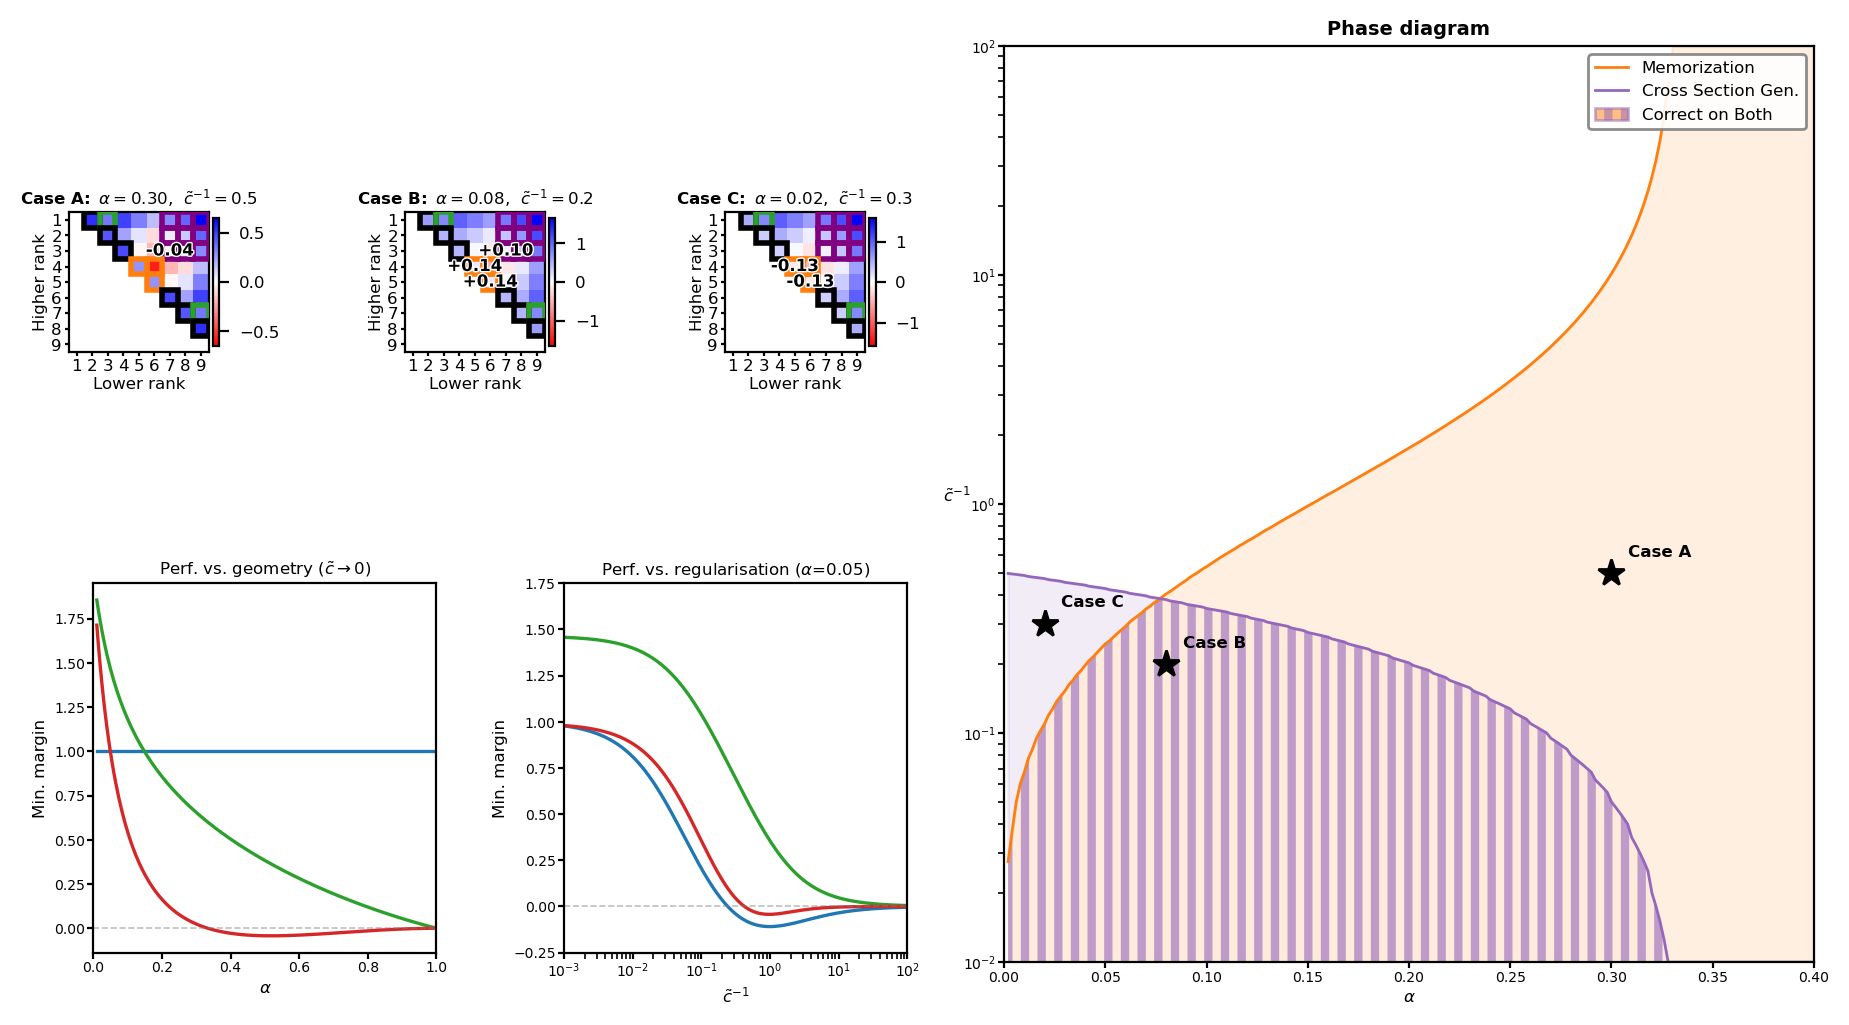

Saved → figure_4_combined.pdf


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# Re-plot only (run cell 9 first to compute data, then tweak layout here)
# ═══════════════════════════════════════════════════════════════════════════

with plt.rc_context({'hatch.linewidth': 3.0, 'figure.dpi': 200}):
    fig = plt.figure(figsize=(2 * FIG_W_IN, FIG_W_IN * 1.1), layout='constrained')

    sf_left, sf_right = fig.subfigures(1, 2, width_ratios=[1.0, 1.0], wspace=0.02)
    sf_top, sf_bot = sf_left.subfigures(2, 1, height_ratios=[1.0, 0.85], hspace=0.02)

    # ── top-left: heatmaps (3 columns) ───────────────────────────────────
    gs_heat = sf_top.add_gridspec(1, 3, wspace=0.15)
    conditions = [((1 - a) / 2 * delta_s + k_d, c_inv) for a, c_inv, _ in conditions_alpha]

    for col_idx, ((k_o_c, c_inv_c), (alpha_c, _, case_label)) in enumerate(
            zip(conditions, conditions_alpha)):
        c_reg_c = 1.0 / (c_inv_c * delta_s)
        df = build_fjk_df(n, p, q, k_o_c, c_reg_c, k_s, k_d)
        sub = df[df["phase"] == "post"].copy()
        M_m, tm, em, wgm, agm = _build_matrix(sub, "margin")
        ext = max(abs(np.nanmax(M_m)), abs(np.nanmin(M_m)), 0.1)
        ax_h = sf_top.add_subplot(gs_heat[0, col_idx])
        _draw_matrix(ax_h, M_m, tm, em, wgm, agm,
                     cmap="bwr_r", vmin=-ext, vmax=ext, fmt="+.2f",
                     annotate_cells=annotate_cells_map.get(col_idx, []))
        ax_h.set_title(
            f"{title_prefix_map.get(col_idx, '')}$\\alpha={alpha_c:.2f}$,  "
            f"$\\tilde{{c}}^{{-1}}={c_inv_c}$",
            fontsize=6, pad=3)

    # ── bottom-left: 3b part 1 (left) and 3b part 2 (right) ──────────────
    sf_bot.get_layout_engine().set(w_pad=1/72, h_pad=1/72)
    gs_bot = sf_bot.add_gridspec(1, 2, wspace=0.05)

    ax_3b1 = sf_bot.add_subplot(gs_bot[0, 0])
    ax_3b1.plot(alphas_3b1, mem_perf_3b1, lw=1.2, color='#1f77b4', label='Memorization')
    ax_3b1.plot(alphas_3b1, within_perf_3b1, lw=1.2, color='#2ca02c', label='Within-section gen.')
    ax_3b1.plot(alphas_3b1, cross_perf_3b1, lw=1.2, color='#d62728', label='Cross-section gen.')
    ax_3b1.axhline(0, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax_3b1.set_xlabel(r'$\alpha$', fontsize=6, labelpad=2)
    ax_3b1.set_ylabel('Min. margin', fontsize=6, labelpad=2)
    ax_3b1.set_title(rf'Perf. vs. geometry ($\tilde{{c}}\to 0$)', fontsize=6, pad=3)
    # ax_3b1.legend(fontsize=6, framealpha=0.8, bbox_to_anchor=(0.5, 1.18), loc='center', ncol=1)
    ax_3b1.set_xlim(0, 1)
    ax_3b1.tick_params(axis='both', labelsize=5, length=2, pad=1)

    ax_3b2 = sf_bot.add_subplot(gs_bot[0, 1])
    ax_3b2.plot(c_inv_vals, mem_perf_3b2, lw=1.2, color='#1f77b4', label='Memorization')
    ax_3b2.plot(c_inv_vals, within_perf_3b2, lw=1.2, color='#2ca02c', label='Within-section gen.')
    ax_3b2.plot(c_inv_vals, cross_perf_3b2, lw=1.2, color='#d62728', label='Cross-section gen.')
    ax_3b2.axhline(0, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax_3b2.set_xscale('log')
    ax_3b2.set_xlabel(r'$\tilde{c}^{-1}$', fontsize=6, labelpad=2)
    ax_3b2.set_ylabel('Min. margin', fontsize=6, labelpad=2)
    ax_3b2.set_title(rf'Perf. vs. regularisation ($\alpha$={alpha_fixed})', fontsize=6, pad=3)
    # ax_3b2.legend(fontsize=6, framealpha=0.8, bbox_to_anchor=(0.5, 1.18), loc='center', ncol=1)
    ax_3b2.set_xlim(c_inv_vals[0], c_inv_vals[-1])
    ax_3b2.set_ylim(-0.25, 1.75)
    ax_3b2.tick_params(axis='both', labelsize=5, length=2, pad=1)

    # ── right: phase diagram ─────────────────────────────────────────────
    ax_pd = sf_right.add_subplot(111)

    ylim_bot = 1e-2
    ylim_top = 1e2
    train_fill   = np.where(np.isnan(breaking_reg_train), ylim_top, breaking_reg_train)
    test_fill    = np.where(np.isnan(breaking_reg_test),  ylim_top, breaking_reg_test)
    overlap_fill = np.minimum(train_fill, test_fill)

    ax_pd.plot(alpha_vals_pd, breaking_reg_train, lw=1.0, color=ORANGE, label='Memorization')
    ax_pd.plot(alpha_vals_pd, breaking_reg_test,  lw=1.0, color=PURPLE, label='Cross Section Gen.')

    ax_pd.fill_between(alpha_vals_pd, overlap_fill, train_fill,
                        where=(train_fill > test_fill), interpolate=True,
                        alpha=0.12, color=ORANGE)
    ax_pd.fill_between(alpha_vals_pd, overlap_fill, test_fill,
                        where=(test_fill > train_fill), interpolate=True,
                        alpha=0.12, color=PURPLE)
    ax_pd.fill_between(alpha_vals_pd, ylim_bot, overlap_fill,
                        facecolor=ORANGE, alpha=0.15)
    ax_pd.fill_between(alpha_vals_pd, ylim_bot, overlap_fill, facecolor='none',
                        edgecolor=PURPLE, hatch='||', linewidth=0, alpha=0.6)
    ax_pd.add_patch(mpatches.Rectangle((0,0),0,0,
                     facecolor=ORANGE, edgecolor=PURPLE, hatch='||',
                     alpha=0.5, label='Correct on Both'))

    for alpha_c, c_inv_c, case_lbl in conditions_alpha:
        ax_pd.plot(alpha_c, c_inv_c, marker='*', markersize=10, color='black', zorder=5)
        ax_pd.annotate(f'Case {case_lbl}', (alpha_c, c_inv_c),
                        textcoords='offset points', xytext=(6, 6),
                        fontsize=6, fontweight='bold')

    ax_pd.set_xlabel(r'$\alpha$', fontsize=6, labelpad=2)
    ax_pd.set_ylabel(r'$\tilde{c}^{-1}$', fontsize=6, rotation=0, labelpad=2)
    ax_pd.set_title('Phase diagram', fontsize=7, fontweight='bold', pad=4)
    ax_pd.legend(fontsize=6, framealpha=0.9, edgecolor='gray', loc='upper right')
    ax_pd.tick_params(axis='both', length=2, pad=1, labelsize=5)
    ax_pd.set_yscale('log')
    ax_pd.set_xlim(0.0, 0.40)
    ax_pd.set_ylim(ylim_bot, ylim_top)
    ax_pd.grid(False)

    plt.show()
    fig.savefig("figure_4_combined.pdf", bbox_inches="tight")
    print("Saved → figure_4_combined.pdf")

n=9, p=6, q=4:   0%|          | 0/200 [00:00<?, ?it/s]

n=11, p=7, q=5:   0%|          | 0/200 [00:00<?, ?it/s]

n=11, p=8, q=4:   0%|          | 0/200 [00:00<?, ?it/s]

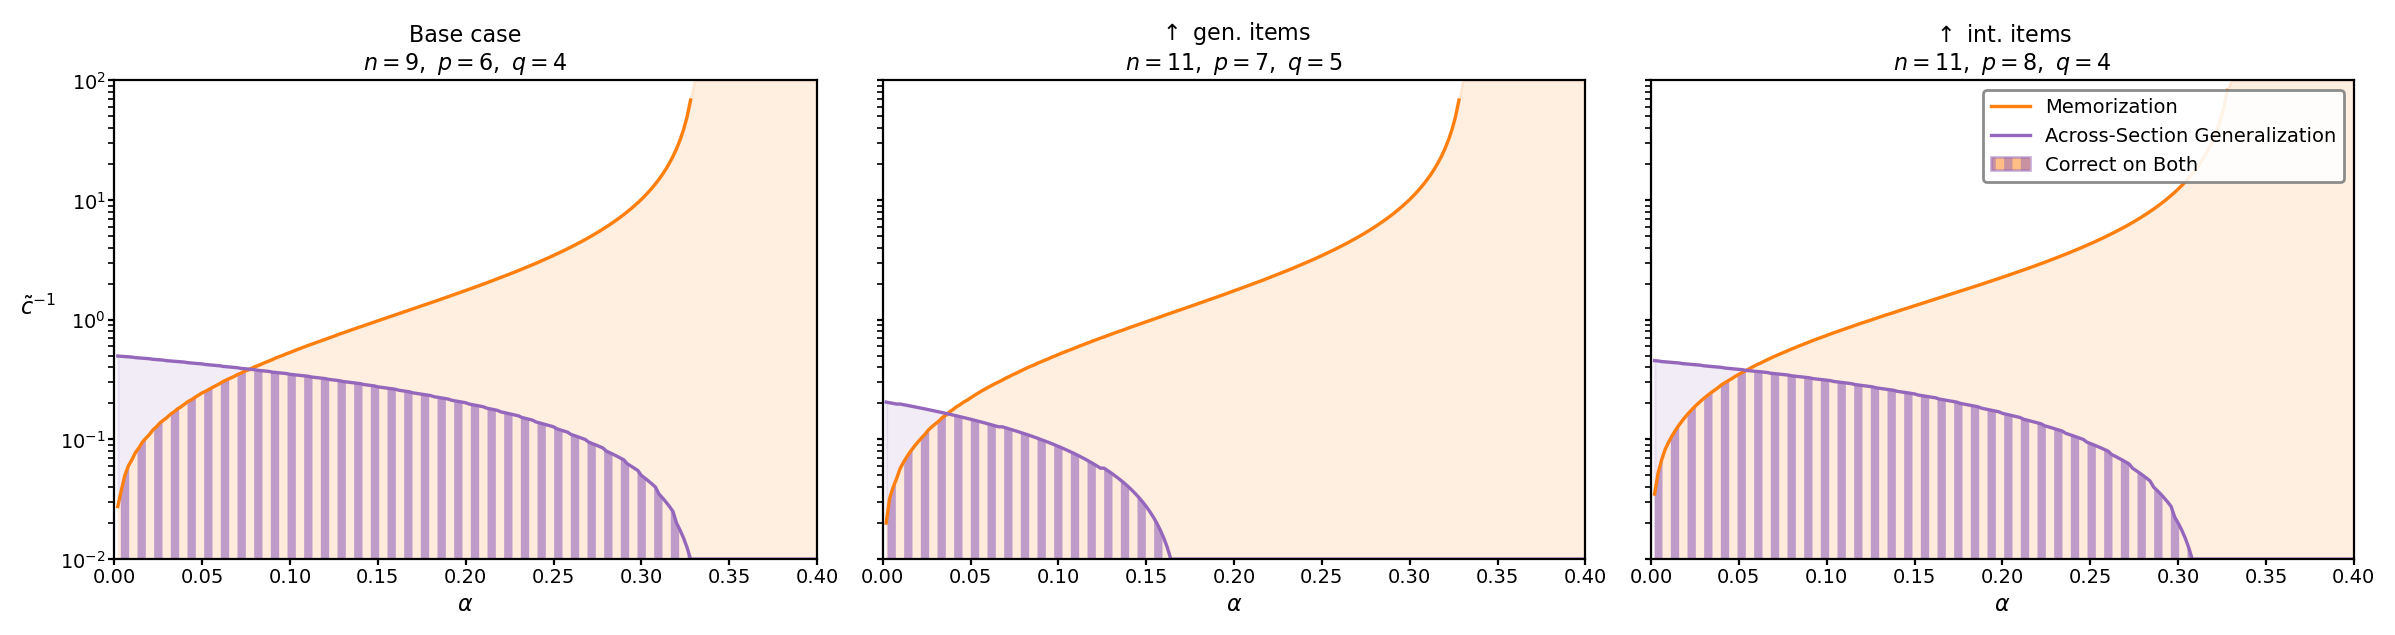

In [81]:
# CELL 9
# 3-panel phase diagram: base case, more generalizable, more interacting items

import sys, os, io, contextlib
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from Ranking_exp import Ranking_exp

# ---------- three parameter sets ------------------------------------------
configs = [
    {'n': 9,  'p': 6, 'q': 4, 'title': 'Base case\n$n=9,\\ p=6,\\ q=4$'},
    {'n': 11, 'p': 7, 'q': 5, 'title': r'$\uparrow$ gen. items' + '\n$n=11,\\ p=7,\\ q=5$'},
    {'n': 11, 'p': 8, 'q': 4, 'title': r'$\uparrow$ int. items' + '\n$n=11,\\ p=8,\\ q=4$'},
]

k_s = 1.0
k_d = 0.0
delta_s = k_s - k_d

k_o_vals   = np.arange(0.30, 0.4999, 0.001)
alpha_vals = 1.0 - 2.0 * (k_o_vals - k_d) / (k_s - k_d)
c_var_vals = np.arange(1e-2, 100, 0.0025)
c_vals     = 1.0 / (c_var_vals * delta_s)


def run_sweep(n, p, q):
    """Bisect sweep for one parameter configuration."""
    test_critical_pair  = (q - 1, p + 1)
    train_critical_pair = (q,     q + 1)

    def _make_sim(k_o, cr):
        with contextlib.redirect_stdout(io.StringIO()):
            return Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                               p=p, q=q, c_reg=cr)

    def bisect_flip_both(k_o):
        N = len(c_vals)
        cache = {}

        def sim_at(i):
            if i not in cache:
                cache[i] = _make_sim(k_o, c_vals[i])
            return cache[i]

        def first_flip(pair):
            if sim_at(N - 1).f_j_k(*pair) >= 0:
                return np.nan
            lo, hi = 0, N - 1
            while lo < hi:
                mid = (lo + hi) // 2
                if sim_at(mid).f_j_k(*pair) < 0:
                    hi = mid
                else:
                    lo = mid + 1
            return c_var_vals[lo]

        return first_flip(test_critical_pair), first_flip(train_critical_pair)

    breaking_test  = np.zeros_like(k_o_vals)
    breaking_train = np.zeros_like(k_o_vals)
    for idx, k_o in enumerate(tqdm(k_o_vals, desc=f'n={n}, p={p}, q={q}')):
        breaking_test[idx], breaking_train[idx] = bisect_flip_both(k_o)
    return breaking_test, breaking_train


# ---------- compute all sweeps --------------------------------------------
results = []
for cfg in configs:
    bt, br = run_sweep(cfg['n'], cfg['p'], cfg['q'])
    results.append((bt, br))

# ---------- plot ----------------------------------------------------------
ORANGE = '#ff7f0e'
PURPLE = '#9467bd'
ylim_bot = 1e-2
ylim_top = 1e2

with plt.rc_context({'figure.dpi': 200, 'hatch.linewidth': 3.0}):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)

    for ax, cfg, (test, train) in zip(axes, configs, results):
        train_fill   = np.where(np.isnan(train), ylim_top, train)
        test_fill    = np.where(np.isnan(test),  ylim_top, test)
        overlap_fill = np.minimum(train_fill, test_fill)

        ax.plot(alpha_vals, train, lw=1.2, color=ORANGE, label='Memorization')
        ax.plot(alpha_vals, test,  lw=1.2, color=PURPLE, label='Across-Section Generalization')

        ax.fill_between(alpha_vals, overlap_fill, train_fill,
                        where=(train_fill > test_fill), interpolate=True,
                        alpha=0.12, color=ORANGE)
        ax.fill_between(alpha_vals, overlap_fill, test_fill,
                        where=(test_fill > train_fill), interpolate=True,
                        alpha=0.12, color=PURPLE)

        ax.fill_between(alpha_vals, ylim_bot, overlap_fill,
                        facecolor=ORANGE, alpha=0.15)
        ax.fill_between(alpha_vals, ylim_bot, overlap_fill, facecolor='none',
                        edgecolor=PURPLE, hatch='||', linewidth=0, alpha=0.6)
        ax.add_patch(mpatches.Rectangle((0, 0), 0, 0,
                     facecolor=ORANGE, edgecolor=PURPLE, hatch='||',
                     alpha=0.5, label='Correct on Both'))

        ax.set_xlabel(r'$\alpha$', fontsize=8, labelpad=2)
        ax.set_title(cfg['title'], fontsize=8, pad=4)
        ax.tick_params(axis='both', length=2, pad=1, labelsize=7)
        ax.set_yscale('log')
        ax.set_xlim(0.0, 0.40)
        ax.set_ylim(ylim_bot, ylim_top)
        ax.grid(False)

    axes[0].set_ylabel(r'$\tilde{c}^{-1}$', fontsize=8, rotation=0, labelpad=8)
    axes[-1].legend(fontsize=7, framealpha=0.9, edgecolor='gray', loc='upper right')

    plt.tight_layout(pad=0.8)
    plt.show()
    fig.savefig("figure_4_4_three_panels.pdf", bbox_inches="tight")


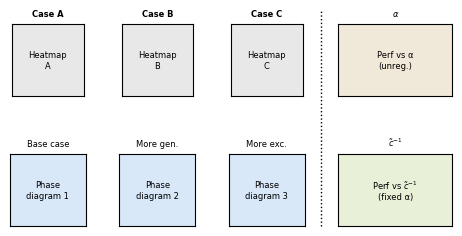

In [76]:
# Dummy layout: 8 panels + vertical dotted divider (GridSpec approach)
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec

FIG_W_IN = 325.48499 / 72.27

fig = plt.figure(figsize=(FIG_W_IN, FIG_W_IN * 0.5), layout='constrained')

# 2 rows × 4 columns: cols 0-2 = left (3 panels each row), col 3 = right
gs = GridSpec(2, 4, figure=fig,
             width_ratios=[1, 1, 1, 1.5],
             height_ratios=[.8, .8],
             wspace=0.3, hspace=0.35)

# ── Top-left: 3 heatmaps (row 0, cols 0-2) ──────────────────────────────
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('#e8e8e8')
    ax.set_title(f'Case {chr(65+i)}', fontsize=6, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.5, f'Heatmap\n{chr(65+i)}', ha='center', va='center',
            fontsize=6, transform=ax.transAxes)
    ax.set_aspect('equal')

# ── Bottom-left: 3 phase diagrams (row 1, cols 0-2) ─────────────────────
titles_phase = ['Base case', 'More gen.', 'More exc.']
for i in range(3):
    ax = fig.add_subplot(gs[1, i])
    ax.set_facecolor('#d8e8f8')
    ax.set_title(titles_phase[i], fontsize=6)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.5, f'Phase\ndiagram {i+1}', ha='center', va='center',
            fontsize=6, transform=ax.transAxes)

# ── Top-right: perf vs geometry (row 0, col 3) ──────────────────────────
ax_tr = fig.add_subplot(gs[0, 3])
ax_tr.set_facecolor('#f0e8d8')
ax_tr.set_title(r'$\alpha$', fontsize=6)
ax_tr.set_xticks([]); ax_tr.set_yticks([])
ax_tr.text(0.5, 0.5, 'Perf vs α\n(unreg.)', ha='center', va='center',
           fontsize=6, transform=ax_tr.transAxes)

# ── Bottom-right: perf vs regularisation (row 1, col 3) ─────────────────
ax_br = fig.add_subplot(gs[1, 3])
ax_br.set_facecolor('#e8f0d8')
ax_br.set_title(r'$\tilde{c}^{-1}$', fontsize=6)
ax_br.set_xticks([]); ax_br.set_yticks([])
ax_br.text(0.5, 0.5, r'Perf vs $\tilde{c}^{-1}$' + '\n(fixed α)', ha='center',
           va='center', fontsize=6, transform=ax_br.transAxes)

# ── Vertical dotted divider ──────────────────────────────────────────────
line = fig.add_artist(mlines.Line2D(
    [0.70, 0.70], [0.02, 0.98],
    transform=fig.transFigure, color='black',
    linestyle=':', linewidth=1.0, zorder=10))

plt.show()

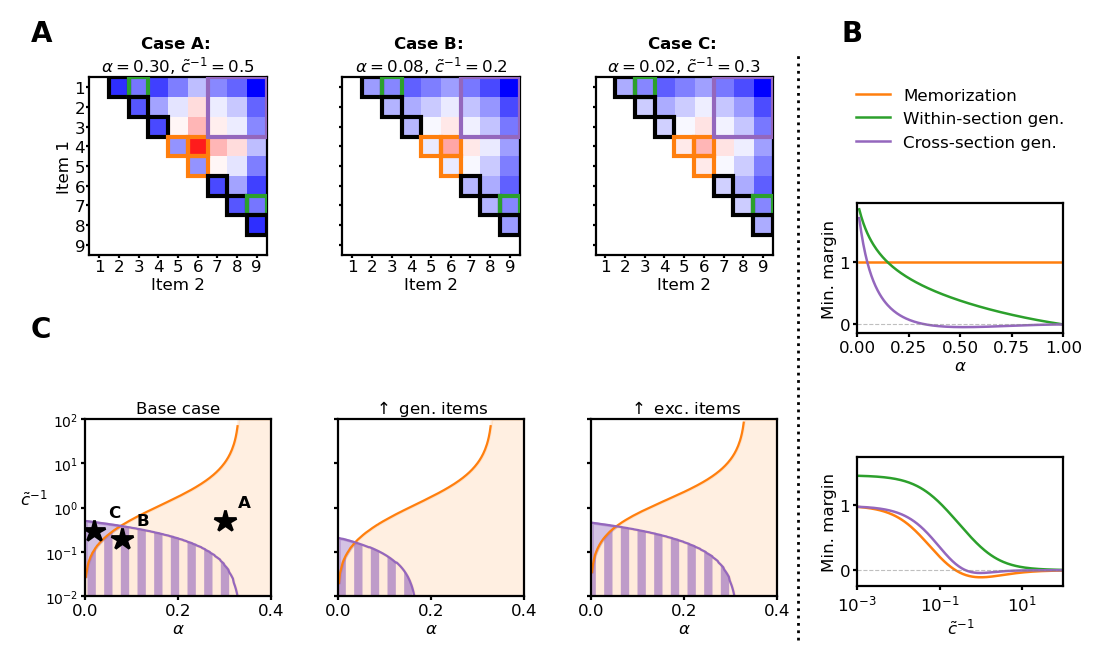

Saved → figure_4_combined.pdf


In [49]:
# ═══════════════════════════════════════════════════════════════════════════
# Combined figure (plot-only): requires cells 9 + 11 to have been run
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.legend_handler import HandlerBase

class HandlerColormap(HandlerBase):
    def __init__(self, cmap, num_stripes=32, **kw):
        super().__init__(**kw)
        self.cmap = cmap
        self.num_stripes = num_stripes
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        stripes = []
        for i in range(self.num_stripes):
            s = plt.Rectangle([xdescent + i * width / self.num_stripes, ydescent], width / self.num_stripes, height, fc=self.cmap((i + 0.5) / self.num_stripes), ec="none", transform=trans)
            stripes.append(s)
        return stripes

def _draw_matrix_no_cb(ax, M, tm, em, wgm, agm, *, cmap, vmin, vmax, fmt,
                       tick_labels=None, annotate_cells=None, p_sec=None, q_sec=None):
    """Like _draw_matrix but without colorbar, for the combined figure."""
    nn = M.shape[0]
    ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
    if annotate_cells:
        for (r1, c1) in annotate_cells:
            r0, c0 = r1 - 1, c1 - 1
            if not np.isnan(M[r0, c0]):
                ax.text(c0, r0, f"{M[r0, c0]:{fmt}}", ha="center", va="center",
                        fontsize=6, color="black", fontweight="bold", zorder=4,
                        path_effects=[pe.withStroke(linewidth=0.8, foreground="white")])
    lw = 1.5
    for i2 in range(nn):
        for j2 in range(nn):
            if tm[i2, j2]:
                ax.add_patch(plt.Rectangle((j2-0.5, i2-0.5), 1, 1, fill=False, edgecolor="black", lw=lw, zorder=3))
            elif em[i2, j2]:
                ax.add_patch(plt.Rectangle((j2-0.5, i2-0.5), 1, 1, fill=False, edgecolor="#ff7f0e", lw=lw, zorder=3))
            elif wgm[i2, j2]:
                ax.add_patch(plt.Rectangle((j2-0.5, i2-0.5), 1, 1, fill=False, edgecolor="#2ca02c", lw=lw, zorder=3))
    # Across-section: block rectangle (upper-right only)
    if p_sec is not None and q_sec is not None:
        n_O1 = q_sec - 1
        n_O2 = nn - p_sec
        ax.add_patch(plt.Rectangle((p_sec - 0.5, -0.5), n_O2, n_O1, fill=False, edgecolor="#9467bd", lw=lw, zorder=3))
    labels = tick_labels if tick_labels is not None else [str(k+1) for k in range(nn)]
    ax.set_xticks(range(nn)); ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(nn)); ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Item 2", fontsize=6, labelpad=1)
    ax.tick_params(axis="both", length=1, pad=0.5)

with plt.rc_context({'hatch.linewidth': 3.0, 'figure.dpi': 200}):
    fig = plt.figure(figsize=(FIG_W_IN*1.2, FIG_W_IN*0.7), layout='constrained')
    fig.get_layout_engine().set(w_pad=4/72, h_pad=6/72, wspace=0.08, hspace=0.30)

    gs = GridSpec(2, 4, figure=fig,
                 width_ratios=[1, 1, 1, 1.5],
                 height_ratios=[1, 1],
                 wspace=0.15, hspace=0.35)

    gs_right = gs[0:2, 3].subgridspec(3, 1, height_ratios=[0.15, 1, 1], hspace=0.4)

    # ── Row 0, cols 0-2: 3 heatmaps (Cases A, B, C) ─────────────────────
    conditions = [((1 - a) / 2 * delta_s + k_d, c_inv) for a, c_inv, _ in conditions_alpha]

    for col_idx, ((k_o_c, c_inv_c), (alpha_c, _, case_label)) in enumerate(
            zip(conditions, conditions_alpha)):
        c_reg_c = 1.0 / (c_inv_c * delta_s)
        df_h = build_fjk_df(n, p, q, k_o_c, c_reg_c, k_s, k_d)
        sub_h = df_h[df_h["phase"] == "post"].copy()
        M_m, tm, em, wgm, agm = _build_matrix(sub_h, "margin")
        ext = max(abs(np.nanmax(M_m)), abs(np.nanmin(M_m)), 0.1)
        ax_h = fig.add_subplot(gs[0, col_idx])
        _draw_matrix_no_cb(ax_h, M_m, tm, em, wgm, agm,
                           cmap="bwr_r", vmin=-ext, vmax=ext, fmt="+.2f",
                           p_sec=p, q_sec=q)
        ax_h.set_title(
            f"{title_prefix_map.get(col_idx, '')}\n$\\alpha={alpha_c:.2f}$, $\\tilde{{c}}^{{-1}}={c_inv_c}$",
            fontsize=6, pad=2)
        if col_idx == 0:
            ax_h.set_ylabel("Item 1", fontsize=6, labelpad=1)
        else:
            ax_h.set_ylabel("")
            ax_h.tick_params(axis='y', labelleft=False)

    # # Gradient color legend for heatmaps
    # cmap_handle = mpatches.Patch()
    # heatmap_leg = fig.legend([cmap_handle], ["Item 1 < Item 2          Item 1 > Item 2"], handler_map={cmap_handle: HandlerColormap(plt.cm.bwr_r)}, fontsize=6, frameon=False, bbox_to_anchor=(0.35, 1.0), loc="upper center", handlelength=4, handleheight=0.8)
    # heatmap_leg.set_in_layout(False)

    # ── Row 1, cols 0-2: 3 phase diagrams ────────────────────────────────
    ylim_bot = 1e-2
    ylim_top = 1e2
    ax_phase_first = None
    
    

    for i, (cfg, (test, train)) in enumerate(zip(configs, results)):
        if i == 0:
            ax_ph = fig.add_subplot(gs[1, i])
            ax_phase_first = ax_ph
        else:
            ax_ph = fig.add_subplot(gs[1, i], sharey=ax_phase_first)

        train_fill   = np.where(np.isnan(train), ylim_top, train)
        test_fill    = np.where(np.isnan(test),  ylim_top, test)
        overlap_fill = np.minimum(train_fill, test_fill)

        ax_ph.plot(alpha_vals, train, lw=0.8, color=ORANGE, label='Memorization')
        ax_ph.plot(alpha_vals, test,  lw=0.8, color=PURPLE, label='Cross Section Gen.')

        ax_ph.fill_between(alpha_vals, overlap_fill, train_fill,
                           where=(train_fill > test_fill), interpolate=True,
                           alpha=0.12, color=ORANGE)
        ax_ph.fill_between(alpha_vals, overlap_fill, test_fill,
                           where=(test_fill > train_fill), interpolate=True,
                           alpha=0.40, color=PURPLE)
        ax_ph.fill_between(alpha_vals, ylim_bot, overlap_fill,
                           facecolor=ORANGE, alpha=0.15)
        ax_ph.fill_between(alpha_vals, ylim_bot, overlap_fill, facecolor='none',
                           edgecolor=PURPLE, hatch='||', linewidth=0, alpha=0.6)
        ax_ph.add_patch(mpatches.Rectangle((0, 0), 0, 0,
                        facecolor=ORANGE, edgecolor=PURPLE, hatch='||',
                        alpha=0.5, label='Correct on Both'))

        ax_ph.set_xlabel(r'$\alpha$', fontsize=6, labelpad=1)
        title_short = cfg['title'].split('\n')[0]
        ax_ph.set_title(title_short, fontsize=6, pad=2)
        ax_ph.tick_params(axis='both', length=1.5, pad=1, labelsize=6)
        ax_ph.tick_params(axis='y', labelsize=5)
        ax_ph.set_yscale('log')
        
        import matplotlib.ticker as ticker
        ax_ph.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=5))
        ax_ph.yaxis.set_minor_locator(ticker.NullLocator())
        
        ax_ph.set_xlim(0.0, 0.40)
        ax_ph.set_ylim(ylim_bot, ylim_top)
        ax_ph.grid(False)

        if i == 0:
            ax_ph.set_ylabel(r'$\tilde{c}^{-1}$', fontsize=6, rotation=0, labelpad=4)
        else:
            ax_ph.set_ylabel("")
            ax_ph.tick_params(axis='y', labelleft=False)

    # ax_phase_first.legend(fontsize=6, framealpha=0.9, edgecolor='gray',
    #                       bbox_to_anchor=(0.5, 1.15), loc='center', ncol=3, handlelength=1.2)

    # Case markers on base case phase diagram
    for alpha_c, c_inv_c, case_lbl in conditions_alpha:
        ax_phase_first.plot(alpha_c, c_inv_c, marker='*', markersize=8, color='black', zorder=5)
        ax_phase_first.annotate(f'{case_lbl}', (alpha_c, c_inv_c),
                               textcoords='offset points', xytext=(5, 5),
                               fontsize=6, fontweight='bold')

    # ── Row 0, col 3: perf vs. geometry (α sweep, unregularized) ─────────
    ax_3b1 = fig.add_subplot(gs_right[1])
    ax_3b1.plot(alphas_3b1, mem_perf_3b1, lw=0.9, color='tab:orange', label='Memorization')
    ax_3b1.plot(alphas_3b1, within_perf_3b1, lw=0.9, color='tab:green', label='Within-section gen.')
    ax_3b1.plot(alphas_3b1, cross_perf_3b1, lw=0.9, color='tab:purple', label='Cross-section gen.')
    ax_3b1.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.5)
    ax_3b1.set_xlabel(r'$\alpha$', fontsize=6, labelpad=1)
    ax_3b1.set_ylabel('Min. margin', fontsize=6, labelpad=1)
    # ax_3b1.set_title(rf'Perf. vs. geometry ($\tilde{{c}}\to 0$)', fontsize=6, pad=2)
    # ax_3b1.legend(fontsize=6, framealpha=0.8, bbox_to_anchor=(0.5, 1.18), loc='center', ncol=1)
    handles, labels = ax_3b1.get_legend_handles_labels()
    leg = ax_3b1.legend(handles, labels, fontsize=6, frameon=False,
                        bbox_to_anchor=(0.5, 1.3), loc='lower center', ncol=1)
    leg.set_in_layout(True)
    ax_3b1.set_xlim(0, 1)
    ax_3b1.tick_params(axis='both', labelsize=6, length=1.5, pad=1)

    # ── Row 1, col 3: perf vs. regularisation (c̃⁻¹ sweep, fixed α) ──────
    ax_3b2 = fig.add_subplot(gs_right[2])
    ax_3b2.plot(c_inv_vals, mem_perf_3b2, lw=0.9, color='tab:orange', label='Memorization')
    ax_3b2.plot(c_inv_vals, within_perf_3b2, lw=0.9, color='tab:green', label='Within-section gen.')
    ax_3b2.plot(c_inv_vals, cross_perf_3b2, lw=0.9, color='tab:purple', label='Cross-section gen.')
    ax_3b2.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.5)
    ax_3b2.set_xscale('log')
    ax_3b2.set_xlabel(r'$\tilde{c}^{-1}$', fontsize=6, labelpad=1)
    ax_3b2.set_ylabel('Min. margin', fontsize=6, labelpad=1)
    # ax_3b2.set_title(rf'Perf. vs. regularisation ($\alpha$={alpha_fixed})', fontsize=6, pad=2)
    # ax_3b2.legend(fontsize=6, framealpha=0.8, bbox_to_anchor=(0.5, 1.18), loc='center', ncol=1)
    ax_3b2.set_xlim(c_inv_vals[0], c_inv_vals[-1])
    ax_3b2.set_ylim(-0.25, 1.75)
    ax_3b2.tick_params(axis='both', labelsize=6, length=1.5, pad=1)

    # ── Vertical dotted divider ──────────────────────────────────────────
    fig.add_artist(mlines.Line2D(
        [0.73, 0.73], [0.02, 0.95],
        transform=fig.transFigure, color='black',
        linestyle=':', linewidth=1.0, zorder=10))
    fig.text(0.02, 0.97, 'A', fontsize=10, fontweight='bold')   # heatmaps (top-left)
    fig.text(0.77, 0.97, 'B', fontsize=10, fontweight='bold')   # right column (top-right)
    fig.text(0.02, 0.50, 'C', fontsize=10, fontweight='bold')   # phase diagrams (bottom-left)
    plt.show()
    fig.savefig("figure_4_combined.pdf", bbox_inches="tight")
    print("Saved → figure_4_combined.pdf")

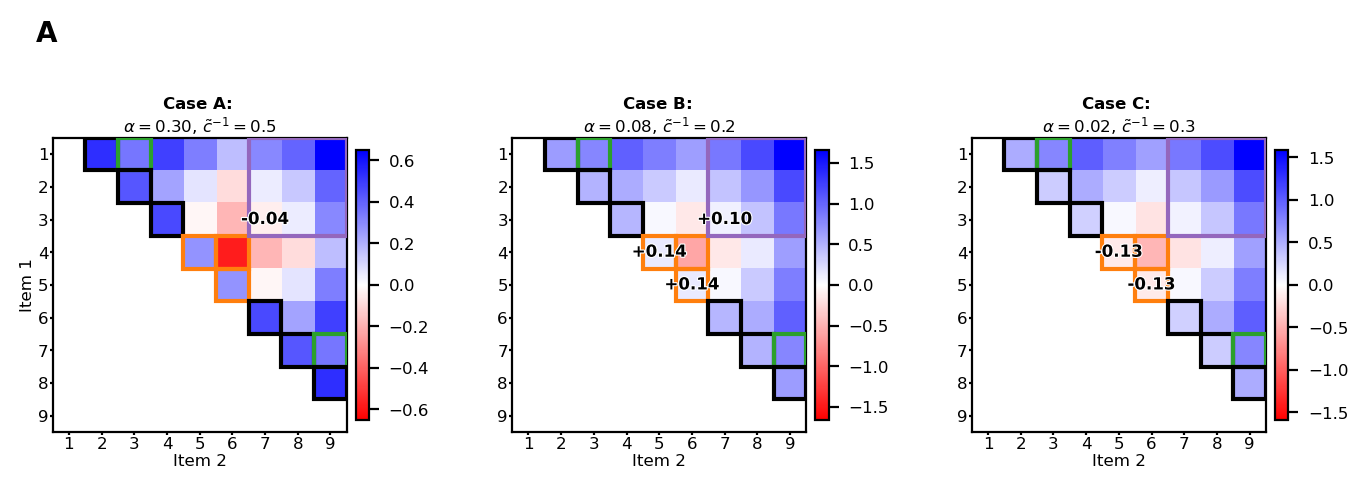

Saved → figure_4_3a_standalone.pdf


In [45]:
# ═══════════════════════════════════════════════════════════════════════════
# Standalone Panel A: heatmaps only, matching combined figure exactly
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

with plt.rc_context({'hatch.linewidth': 3.0, 'figure.dpi': 200}):
    fig = plt.figure(figsize=(FIG_W_IN * 1.5, FIG_W_IN * 0.6), layout='constrained')
    fig.get_layout_engine().set(w_pad=4/72, h_pad=6/72, wspace=0.08, hspace=0.30)

    gs = GridSpec(
        1, 3,
        figure=fig,
        width_ratios=[1, 1, 1],
        wspace=0.15,
    )

    conditions = [
        ((1 - a) / 2 * delta_s + k_d, c_inv)
        for a, c_inv, _ in conditions_alpha
    ]

    for col_idx, ((k_o_c, c_inv_c), (alpha_c, _, case_label)) in enumerate(
            zip(conditions, conditions_alpha)):
        c_reg_c = 1.0 / (c_inv_c * delta_s)
        df_h = build_fjk_df(n, p, q, k_o_c, c_reg_c, k_s, k_d)
        sub_h = df_h[df_h["phase"] == "post"].copy()
        M_m, tm, em, wgm, agm = _build_matrix(sub_h, "margin")
        ext = max(abs(np.nanmax(M_m)), abs(np.nanmin(M_m)), 0.1)

        ax_h = fig.add_subplot(gs[0, col_idx])
        _draw_matrix_no_cb(
            ax_h, M_m, tm, em, wgm, agm,
            cmap="bwr_r",
            vmin=-ext,
            vmax=ext,
            fmt="+.2f",
            p_sec=p,
            q_sec=q,
            annotate_cells=annotate_cells_map.get(col_idx, [])
        )

        cb = fig.colorbar(
            ax_h.images[0],
            ax=ax_h,
            shrink=0.85,
            pad=0.03,
            fraction=0.046,
        )
        cb.ax.tick_params(labelsize=6)

        ax_h.set_title(
            f"{title_prefix_map.get(col_idx, '')}\n"
            f"$\\alpha={alpha_c:.2f}$, $\\tilde{{c}}^{{-1}}={c_inv_c}$",
            fontsize=6,
            pad=2,
        )

        if col_idx == 0:
            ax_h.set_ylabel("Item 1", fontsize=6, labelpad=1)
        else:
            ax_h.set_ylabel("")

    fig.text(0.02, 0.95, 'A', fontsize=10, fontweight='bold')

    plt.show()
    fig.savefig("figure_4_3a_standalone.pdf", bbox_inches="tight")
    print("Saved → figure_4_3a_standalone.pdf")

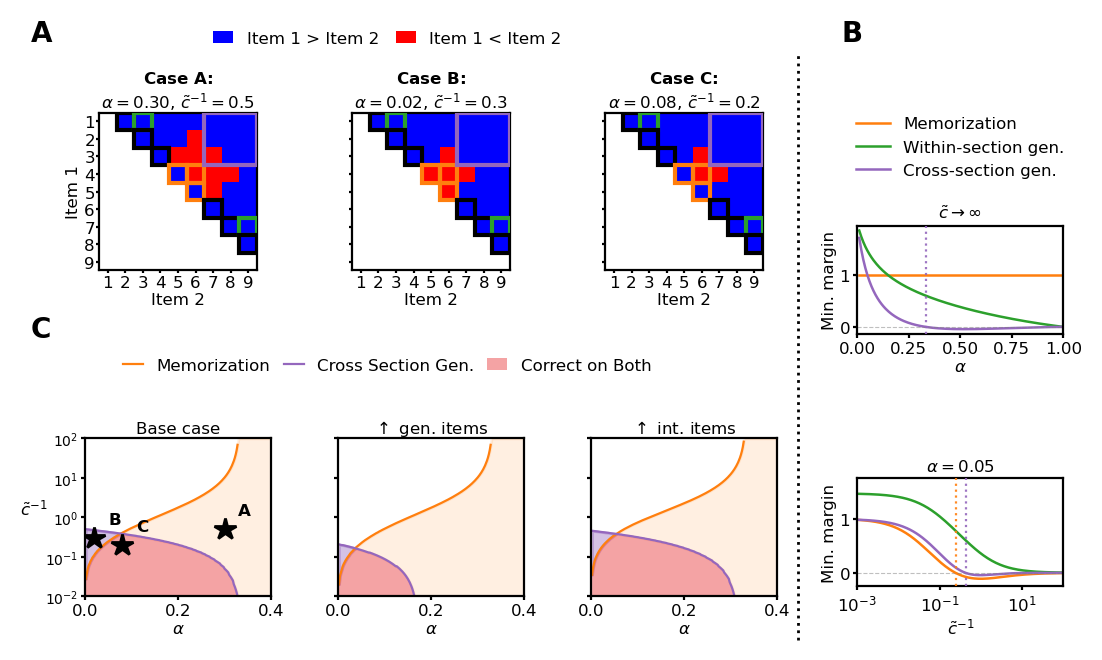

Saved → figure_4_combined.pdf


In [82]:
# ═══════════════════════════════════════════════════════════════════════════
# Combined figure (plot-only): requires cells 9 + 11 to have been run (Now Binary)
# ═══════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.legend_handler import HandlerBase
from matplotlib.colors import ListedColormap, BoundaryNorm

BOTH = "#e41a1c"

# Swap B/C data so Case C = passes memorization + cross-section gen.
conditions_alpha_plot = [
    (1 - 2*0.35, 0.50, 'A'),
    (1 - 2*0.49, 0.30, 'B'),  # old C data
    (1 - 2*0.46, 0.20, 'C'),  # old B data
]

class HandlerColormap(HandlerBase):
    def __init__(self, cmap, num_stripes=32, **kw):
        super().__init__(**kw)
        self.cmap = cmap
        self.num_stripes = num_stripes

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        stripes = []
        for i in range(self.num_stripes):
            s = plt.Rectangle(
                [xdescent + i * width / self.num_stripes, ydescent],
                width / self.num_stripes,
                height,
                fc=self.cmap((i + 0.5) / self.num_stripes),
                ec="none",
                transform=trans,
            )
            stripes.append(s)
        return stripes

def _draw_matrix_no_cb(ax, M, tm, em, wgm, agm, *, cmap, vmin, vmax, fmt,
                       tick_labels=None, annotate_cells=None, p_sec=None, q_sec=None):
    """Like _draw_matrix but without colorbar, for the combined figure."""
    nn = M.shape[0]
    ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")

    if annotate_cells:
        for (r1, c1) in annotate_cells:
            r0, c0 = r1 - 1, c1 - 1
            if not np.isnan(M[r0, c0]):
                ax.text(
                    c0, r0, f"{M[r0, c0]:{fmt}}",
                    ha="center", va="center",
                    fontsize=6, color="black", fontweight="bold", zorder=4,
                    path_effects=[pe.withStroke(linewidth=0.8, foreground="white")],
                )

    lw = 1.5
    for i2 in range(nn):
        for j2 in range(nn):
            if tm[i2, j2]:
                ax.add_patch(plt.Rectangle((j2-0.5, i2-0.5), 1, 1, fill=False, edgecolor="black", lw=lw, zorder=3))
            elif em[i2, j2]:
                ax.add_patch(plt.Rectangle((j2-0.5, i2-0.5), 1, 1, fill=False, edgecolor="#ff7f0e", lw=lw, zorder=3))
            elif wgm[i2, j2]:
                ax.add_patch(plt.Rectangle((j2-0.5, i2-0.5), 1, 1, fill=False, edgecolor="#2ca02c", lw=lw, zorder=3))

    if p_sec is not None and q_sec is not None:
        n_O1 = q_sec - 1
        n_O2 = nn - p_sec
        ax.add_patch(plt.Rectangle((p_sec - 0.5, -0.5), n_O2, n_O1, fill=False, edgecolor="#9467bd", lw=lw, zorder=3))

    labels = tick_labels if tick_labels is not None else [str(k+1) for k in range(nn)]
    ax.set_xticks(range(nn)); ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(nn)); ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Item 2", fontsize=6, labelpad=1)
    ax.tick_params(axis="both", length=1, pad=0.5)

with plt.rc_context({'hatch.linewidth': 3.0, 'figure.dpi': 200}):
    fig = plt.figure(figsize=(FIG_W_IN*1.2, FIG_W_IN*0.7), layout='constrained')
    fig.get_layout_engine().set(
        w_pad=4/72,
        h_pad=6/72,
        wspace=0.08,
        hspace=0.30,
        rect=(0.0, 0.0, 1.0, 0.95),
    )

    gs = GridSpec(
        2, 4,
        figure=fig,
        width_ratios=[1, 1, 1, 1.5],
        height_ratios=[1, 1],
        wspace=0.15,
        hspace=0.35,
        top=0.75,
    )

    gs_right = gs[0:2, 3].subgridspec(3, 1, height_ratios=[0.15, 1, 1], hspace=0.4)

    # ── Row 0, cols 0-2: 3 heatmaps ─────────────────────────────────────
    conditions = [((1 - a) / 2 * delta_s + k_d, c_inv) for a, c_inv, _ in conditions_alpha_plot]

    for col_idx, ((k_o_c, c_inv_c), (alpha_c, _, case_label)) in enumerate(
            zip(conditions, conditions_alpha_plot)):
        c_reg_c = 1.0 / (c_inv_c * delta_s)
        df_h = build_fjk_df(n, p, q, k_o_c, c_reg_c, k_s, k_d)
        sub_h = df_h[df_h["phase"] == "post"].copy()
        M_m, tm, em, wgm, agm = _build_matrix(sub_h, "margin")
        M_bin = np.where(np.isnan(M_m), np.nan, (M_m > 0).astype(float))

        binary_cmap = ListedColormap([plt.cm.bwr_r(0.0), plt.cm.bwr_r(1.0)])
        binary_cmap.set_bad("white")

        ax_h = fig.add_subplot(gs[0, col_idx])
        _draw_matrix_no_cb(
            ax_h, M_bin, tm, em, wgm, agm,
            cmap=binary_cmap,
            vmin=-0.5,
            vmax=1.5,
            fmt=".0f",
            p_sec=p,
            q_sec=q,
        )

        ax_h.set_title(
            f"$\\mathbf{{Case\\ {case_label}\\!:}}$\n"
            f"$\\alpha={alpha_c:.2f}$, $\\tilde{{c}}^{{-1}}={c_inv_c}$",
            fontsize=6,
            pad=2,
        )

        if col_idx == 0:
            ax_h.set_ylabel("Item 1", fontsize=6, labelpad=1)
        else:
            ax_h.set_ylabel("")
            ax_h.tick_params(axis='y', labelleft=False)

    # ── Row 1, cols 0-2: 3 phase diagrams ───────────────────────────────
    ylim_bot = 1e-2
    ylim_top = 1e2
    ax_phase_first = None

    for i, (cfg, (test, train)) in enumerate(zip(configs, results)):
        if i == 0:
            ax_ph = fig.add_subplot(gs[1, i])
            ax_phase_first = ax_ph
        else:
            ax_ph = fig.add_subplot(gs[1, i], sharey=ax_phase_first)

        train_fill   = np.where(np.isnan(train), ylim_top, train)
        test_fill    = np.where(np.isnan(test),  ylim_top, test)
        overlap_fill = np.minimum(train_fill, test_fill)

        ax_ph.plot(alpha_vals, train, lw=0.8, color=ORANGE, label='Memorization')
        ax_ph.plot(alpha_vals, test,  lw=0.8, color=PURPLE, label='Cross Section Gen.')

        ax_ph.fill_between(alpha_vals, overlap_fill, train_fill,
                           where=(train_fill > test_fill), interpolate=True,
                           alpha=0.12, color=ORANGE)
        ax_ph.fill_between(alpha_vals, overlap_fill, test_fill,
                           where=(test_fill > train_fill), interpolate=True,
                           alpha=0.40, color=PURPLE)
        ax_ph.fill_between(alpha_vals, ylim_bot, overlap_fill,
                           facecolor=BOTH, alpha=0.40)
        ax_ph.add_patch(mpatches.Rectangle((0, 0), 0, 0,
                                           facecolor=BOTH, edgecolor='none',
                                           alpha=0.40, label='Correct on Both'))

        ax_ph.set_xlabel(r'$\alpha$', fontsize=6, labelpad=1)
        title_short = cfg['title'].split('\n')[0]
        ax_ph.set_title(title_short, fontsize=6, pad=2)
        ax_ph.tick_params(axis='both', length=1.5, pad=1, labelsize=6)
        ax_ph.tick_params(axis='y', labelsize=5)
        ax_ph.set_yscale('log')

        import matplotlib.ticker as ticker
        ax_ph.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=5))
        ax_ph.yaxis.set_minor_locator(ticker.NullLocator())

        ax_ph.set_xlim(0.0, 0.40)
        ax_ph.set_ylim(ylim_bot, ylim_top)
        ax_ph.grid(False)

        if i == 0:
            ax_ph.set_ylabel(r'$\tilde{c}^{-1}$', fontsize=6, rotation=0, labelpad=4)
        else:
            ax_ph.set_ylabel("")
            ax_ph.tick_params(axis='y', labelleft=False)

    phase_handles, phase_labels = ax_phase_first.get_legend_handles_labels()
    phase_leg = fig.legend(
        phase_handles,
        phase_labels,
        fontsize=6,
        frameon=False,
        bbox_to_anchor=(0.35, 0.42),
        loc="lower center",
        ncol=3,
        handlelength=1.2,
        columnspacing=0.8,
    )
    phase_leg.set_in_layout(False)

    for alpha_c, c_inv_c, case_lbl in conditions_alpha_plot:
        ax_phase_first.plot(alpha_c, c_inv_c, marker='*', markersize=8, color='black', zorder=5)
        ax_phase_first.annotate(f'{case_lbl}', (alpha_c, c_inv_c),
                               textcoords='offset points', xytext=(5, 5),
                               fontsize=6, fontweight='bold')

    heatmap_legend_elements = [
        mpatches.Patch(facecolor=plt.cm.bwr_r(1.0), label="Item 1 > Item 2"),
        mpatches.Patch(facecolor=plt.cm.bwr_r(0.0), label="Item 1 < Item 2"),
    ]

    heatmap_leg = fig.legend(
        handles=heatmap_legend_elements,
        fontsize=6,
        frameon=False,
        bbox_to_anchor=(0.35, 1.01),
        loc="upper center",
        ncol=2,
        handlelength=1.2,
        columnspacing=1.0,
    )
    heatmap_leg.set_in_layout(False)

    # ── Right column, top: perf vs. geometry ─────────────────────────────
    ax_3b1 = fig.add_subplot(gs_right[1])
    ax_3b1.plot(alphas_3b1, mem_perf_3b1, lw=0.9, color='tab:orange', label='Memorization')
    ax_3b1.plot(alphas_3b1, within_perf_3b1, lw=0.9, color='tab:green', label='Within-section gen.')
    ax_3b1.plot(alphas_3b1, cross_perf_3b1, lw=0.9, color='tab:purple', label='Cross-section gen.')
    ax_3b1.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.5)
    cross_sign_changes = np.where(np.diff(np.signbit(cross_perf_3b1)))[0]
    if len(cross_sign_changes) > 0:
        z_idx = cross_sign_changes[0]
        x0, x1 = alphas_3b1[z_idx], alphas_3b1[z_idx + 1]
        y0, y1 = cross_perf_3b1[z_idx], cross_perf_3b1[z_idx + 1]
        alpha_cross_zero = x0 - y0 * (x1 - x0) / (y1 - y0) if y1 != y0 else x0
        ax_3b1.axvline(alpha_cross_zero, color='tab:purple', lw=0.8, ls=':', alpha=0.9, zorder=4)
    ax_3b1.text(0.5, 1.04, r'$\tilde{c}\to\infty$',
                transform=ax_3b1.transAxes, ha='center', va='bottom',
                fontsize=6, clip_on=False)
    ax_3b1.set_xlabel(r'$\alpha$', fontsize=6, labelpad=1)
    ax_3b1.set_ylabel('Min. margin', fontsize=6, labelpad=1)
    handles, labels = ax_3b1.get_legend_handles_labels()
    leg = ax_3b1.legend(handles, labels, fontsize=6, frameon=False,
                        bbox_to_anchor=(0.5, 1.3), loc='lower center', ncol=1)
    leg.set_in_layout(True)
    ax_3b1.set_xlim(0, 1)
    ax_3b1.tick_params(axis='both', labelsize=6, length=1.5, pad=1)

    # ── Right column, bottom: perf vs. regularisation ────────────────────
    ax_3b2 = fig.add_subplot(gs_right[2])
    ax_3b2.plot(c_inv_vals, mem_perf_3b2, lw=0.9, color='tab:orange', label='Memorization')
    ax_3b2.plot(c_inv_vals, within_perf_3b2, lw=0.9, color='tab:green', label='Within-section gen.')
    ax_3b2.plot(c_inv_vals, cross_perf_3b2, lw=0.9, color='tab:purple', label='Cross-section gen.')
    ax_3b2.axhline(0, color='gray', lw=0.4, ls='--', alpha=0.5)
    for perf_vals, zero_color in [(mem_perf_3b2, 'tab:orange'), (cross_perf_3b2, 'tab:purple')]:
        zero_changes = np.where(np.diff(np.signbit(perf_vals)))[0]
        if len(zero_changes) > 0:
            z_idx = zero_changes[0]
            x0, x1 = c_inv_vals[z_idx], c_inv_vals[z_idx + 1]
            y0, y1 = perf_vals[z_idx], perf_vals[z_idx + 1]
            log_x0, log_x1 = np.log10(x0), np.log10(x1)
            log_zero = log_x0 - y0 * (log_x1 - log_x0) / (y1 - y0) if y1 != y0 else log_x0
            ax_3b2.axvline(10 ** log_zero, color=zero_color, lw=0.8, ls=':', alpha=0.9, zorder=4)
    ax_3b2.text(0.5, 1.04, rf'$\alpha={alpha_fixed}$',
                transform=ax_3b2.transAxes, ha='center', va='bottom',
                fontsize=6, clip_on=False)
    ax_3b2.set_xscale('log')
    ax_3b2.set_xlabel(r'$\tilde{c}^{-1}$', fontsize=6, labelpad=1)
    ax_3b2.set_ylabel('Min. margin', fontsize=6, labelpad=1)
    ax_3b2.set_xlim(c_inv_vals[0], c_inv_vals[-1])
    ax_3b2.set_ylim(-0.25, 1.75)
    ax_3b2.tick_params(axis='both', labelsize=6, length=1.5, pad=1)

    fig.add_artist(mlines.Line2D(
        [0.73, 0.73], [0.02, 0.95],
        transform=fig.transFigure, color='black',
        linestyle=':', linewidth=1.0, zorder=10))

    fig.text(0.02, 0.97, 'A', fontsize=10, fontweight='bold')
    fig.text(0.77, 0.97, 'B', fontsize=10, fontweight='bold')
    fig.text(0.02, 0.50, 'C', fontsize=10, fontweight='bold')

    plt.show()
    fig.savefig("figure_4_combined.pdf", bbox_inches="tight")
    print("Saved → figure_4_combined.pdf")